In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Wczytanie danych PM10 dla dwóch wybranych miast
gliwice = pd.read_excel("Miasta/Gliwice 24h 2007-2014.xlsx", header=3)
tychy = pd.read_excel("Miasta/Tychy 24h 2007-2014.xlsx", header=3)

print("Gliwice:")
display(gliwice.head())

print("Tychy:")
display(tychy.head())

Gliwice:


,Unnamed: 0,NO,NO2,NOx,PM10,PM2.5,SO2,cisnienie,kier,opad_atm,predk,prom,temp,wilg
0,Data,1g,1g,1g,1g,24g,1g,1g,1g,1g,1g,1g,1g,1g
1,2007-01-01,NaN,9.521739,NaN,14.666667,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-01-02,NaN,17.347826,NaN,22.291667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007-01-03,NaN,17.47619,NaN,17.217391,NaN,2.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-01-04,NaN,20.047619,NaN,13.333333,NaN,10.952381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tychy:


,Unnamed: 0,NO,NO2,NOx,O3,PM10,SO2,cisnienie,kier,opad_atm,predk,prom,temp,wilg
0,Data,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g
1,2007-01-01,NaN,11.217391,NaN,50.416667,10.125,9.608696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-01-02,NaN,17.956522,NaN,42.652174,17.291667,9.869565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007-01-03,NaN,17.652174,NaN,33.608696,18.583333,8.782609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-01-04,NaN,11.956522,NaN,44.782609,8.333333,8.173913,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dane dotyczące zanieczyszczenia powietrza zostały wczytane z plików Excel dla dwóch miast: Gliwic i Tychów. W analizie wykorzystano zmienną PM10, czyli średnie dobowe stężenie pyłu zawieszonego.

In [2]:
# Uporządkowanie danych z plików miejskich

gliwice = gliwice.rename(columns={"Unnamed: 0": "Data"})
tychy = tychy.rename(columns={"Unnamed: 0": "Data"})

# Usunięcie technicznego wiersza z jednostkami pomiaru
gliwice = gliwice[gliwice["Data"] != "Data"].copy()
tychy = tychy[tychy["Data"] != "Data"].copy()

# Konwersja daty i PM10 do poprawnych typów danych
gliwice["Data"] = pd.to_datetime(gliwice["Data"], errors="coerce")
tychy["Data"] = pd.to_datetime(tychy["Data"], errors="coerce")

gliwice["PM10"] = pd.to_numeric(gliwice["PM10"], errors="coerce")
tychy["PM10"] = pd.to_numeric(tychy["PM10"], errors="coerce")

# Pozostawienie tylko kolumn potrzebnych w projekcie
gliwice = gliwice[["Data", "PM10"]].copy()
tychy = tychy[["Data", "PM10"]].copy()

display(gliwice.head())
display(tychy.head())

,Data,PM10
1,2007-01-01,14.666667
2,2007-01-02,22.291667
3,2007-01-03,17.217391
4,2007-01-04,13.333333
5,2007-01-05,13.791667


,Data,PM10
1,2007-01-01,10.125000
2,2007-01-02,17.291667
3,2007-01-03,18.583333
4,2007-01-04,8.333333
5,2007-01-05,17.625000


In [3]:
# Przygotowanie dziennych danych PM10 dla obu miast

gliwice_pm10 = gliwice[["Data", "PM10"]].copy()
gliwice_pm10["Miasto"] = "Gliwice"

tychy_pm10 = tychy[["Data", "PM10"]].copy()
tychy_pm10["Miasto"] = "Tychy"

pm10_daily_raw = pd.concat([gliwice_pm10, tychy_pm10], ignore_index=True)

pm10_daily_raw["Data"] = pd.to_datetime(pm10_daily_raw["Data"], errors="coerce")
pm10_daily_raw["PM10"] = pd.to_numeric(pm10_daily_raw["PM10"], errors="coerce")

# W razie duplikatów dla tego samego dnia i miasta liczymy średnią
pm10_daily_raw = (
    pm10_daily_raw
    .groupby(["Data", "Miasto"], as_index=False)["PM10"]
    .mean()
)

# Tworzymy pełną siatkę dni 2007-2014 dla obu miast
all_days = pd.date_range("2007-01-01", "2014-12-31", freq="D")
cities = ["Gliwice", "Tychy"]

full_daily_grid = pd.MultiIndex.from_product(
    [all_days, cities],
    names=["Data", "Miasto"]
).to_frame(index=False)

# Do pełnej siatki dołączamy dostępne pomiary PM10
pm10_daily = full_daily_grid.merge(
    pm10_daily_raw,
    on=["Data", "Miasto"],
    how="left"
)

pm10_daily["Rok"] = pm10_daily["Data"].dt.year
pm10_daily["Miesiac"] = pm10_daily["Data"].dt.month

# Analiza braków w dziennych danych PM10
braki_pm10_daily = (
    pm10_daily
    .groupby("Miasto")["PM10"]
    .agg(
        liczba_dni="size",
        liczba_brakow=lambda x: x.isna().sum(),
        liczba_dni_z_pomiarem=lambda x: x.notna().sum(),
        procent_brakow=lambda x: x.isna().mean() * 100
    )
    .reset_index()
)

display(braki_pm10_daily)
display(pm10_daily.head())

,Miasto,liczba_dni,liczba_brakow,liczba_dni_z_pomiarem,procent_brakow
0,Gliwice,2922,389,2533,13.312799
1,Tychy,2922,242,2680,8.281999


,Data,Miasto,PM10,Rok,Miesiac
0,2007-01-01,Gliwice,14.666667,2007,1
1,2007-01-01,Tychy,10.125000,2007,1
2,2007-01-02,Gliwice,22.291667,2007,1
3,2007-01-02,Tychy,17.291667,2007,1
4,2007-01-03,Gliwice,17.217391,2007,1


In [4]:
# Agregacja PM10 do poziomu miesięcznego z oceną kompletności pomiarów

pm10_month = (
    pm10_daily
    .groupby(["Rok", "Miesiac", "Miasto"])
    .agg(
        PM10_przed_uzupelnieniem=("PM10", "mean"),
        liczba_dni_w_miesiacu=("PM10", "size"),
        liczba_dni_z_pomiarem=("PM10", lambda x: x.notna().sum()),
        liczba_brakow_PM10=("PM10", lambda x: x.isna().sum())
    )
    .reset_index()
)

pm10_month["procent_dni_z_pomiarem"] = (
    pm10_month["liczba_dni_z_pomiarem"] / pm10_month["liczba_dni_w_miesiacu"] * 100
)

pm10_month["procent_brakow_PM10"] = (
    pm10_month["liczba_brakow_PM10"] / pm10_month["liczba_dni_w_miesiacu"] * 100
)

pm10_month["Data"] = pd.to_datetime(
    pm10_month["Rok"].astype(str) + "-" + pm10_month["Miesiac"].astype(str) + "-01"
)

# Oznaczenie miesięcy o słabszej kompletności pomiarów
prog_poprawnych_dni = 75

pm10_month["slaby_miesiac_PM10"] = (
    pm10_month["procent_dni_z_pomiarem"] < prog_poprawnych_dni
)

display(pm10_month.head())

print("Miesiące z mniej niż 75% dni z pomiarem PM10:")
display(
    pm10_month[pm10_month["slaby_miesiac_PM10"] == True][
        [
            "Rok", "Miesiac", "Miasto",
            "PM10_przed_uzupelnieniem",
            "liczba_dni_w_miesiacu",
            "liczba_dni_z_pomiarem",
            "procent_dni_z_pomiarem"
        ]
    ]
)

,Rok,Miesiac,Miasto,PM10_przed_uzupelnieniem,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,liczba_brakow_PM10,procent_dni_z_pomiarem,procent_brakow_PM10,Data,slaby_miesiac_PM10
0,2007,1,Gliwice,19.187994,31,31,0,100.000000,0.000000,2007-01-01,False
1,2007,1,Tychy,19.922421,31,30,1,96.774194,3.225806,2007-01-01,False
2,2007,2,Gliwice,38.279270,28,22,6,78.571429,21.428571,2007-02-01,False
3,2007,2,Tychy,43.105945,28,28,0,100.000000,0.000000,2007-02-01,False
4,2007,3,Gliwice,62.601449,31,31,0,100.000000,0.000000,2007-03-01,False


Miesiące z mniej niż 75% dni z pomiarem PM10:


,Rok,Miesiac,Miasto,PM10_przed_uzupelnieniem,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,procent_dni_z_pomiarem
5,2007,3,Tychy,49.478103,31,23,74.193548
22,2007,12,Gliwice,26.065217,31,23,74.193548
24,2008,1,Gliwice,37.312112,31,21,67.741935
27,2008,2,Tychy,35.000000,29,7,24.137931
29,2008,3,Tychy,NaN,31,0,0.000000
31,2008,4,Tychy,35.033333,30,5,16.666667
32,2008,5,Gliwice,34.421366,31,19,61.290323
44,2008,11,Gliwice,49.778295,30,21,70.000000
45,2008,11,Tychy,36.839286,30,7,23.333333
47,2008,12,Tychy,NaN,31,0,0.000000


In [5]:
# Uzupełnienie brakujących miesięcznych wartości PM10

pm10_month = pm10_month.sort_values(["Miasto", "Data"]).copy()

# Informacja, czy miesięczna wartość PM10 była pierwotnie brakująca
pm10_month["PM10_byl_brak"] = pm10_month["PM10_przed_uzupelnieniem"].isna()

# Startowo PM10 do analizy to wartość przed uzupełnieniem
pm10_month["PM10"] = pm10_month["PM10_przed_uzupelnieniem"]

# 1) Interpolacja liniowa tylko dla krótkich luk, maksymalnie 2 miesiące pod rząd
pm10_month["PM10_po_interpolacji"] = (
    pm10_month
    .groupby("Miasto")["PM10"]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit=2,
            limit_direction="both",
            limit_area="inside"
        )
    )
)

# Oznaczenie metody uzupełnienia
pm10_month["PM10_metoda"] = "oryginalna wartość miesięczna"

warunek_interpolacja = (
    pm10_month["PM10_byl_brak"] &
    pm10_month["PM10_po_interpolacji"].notna()
)

pm10_month.loc[warunek_interpolacja, "PM10_metoda"] = "interpolacja liniowa krótkiej luki"

# Aktualizacja PM10 po interpolacji krótkich luk
pm10_month["PM10"] = pm10_month["PM10_po_interpolacji"]

# 2) Dłuższe luki: średnia dla tego samego miesiąca kalendarzowego w danym mieście
srednie_miesieczne_pm10 = (
    pm10_month
    .groupby(["Miasto", "Miesiac"])["PM10_przed_uzupelnieniem"]
    .mean()
    .reset_index()
    .rename(columns={"PM10_przed_uzupelnieniem": "PM10_srednia_dla_miesiaca"})
)

pm10_month = pm10_month.merge(
    srednie_miesieczne_pm10,
    on=["Miasto", "Miesiac"],
    how="left"
)

warunek_srednia_miesieczna = pm10_month["PM10"].isna()

pm10_month.loc[warunek_srednia_miesieczna, "PM10"] = (
    pm10_month.loc[warunek_srednia_miesieczna, "PM10_srednia_dla_miesiaca"]
)

pm10_month.loc[warunek_srednia_miesieczna, "PM10_metoda"] = (
    "średnia dla tego samego miesiąca w danym mieście"
)

# 3) Awaryjnie: jeśli nadal są braki, uzupełniamy średnią dla miasta
srednie_miasta_pm10 = (
    pm10_month
    .groupby("Miasto")["PM10_przed_uzupelnieniem"]
    .mean()
    .reset_index()
    .rename(columns={"PM10_przed_uzupelnieniem": "PM10_srednia_miasta"})
)

pm10_month = pm10_month.merge(
    srednie_miasta_pm10,
    on="Miasto",
    how="left"
)

warunek_srednia_miasta = pm10_month["PM10"].isna()

pm10_month.loc[warunek_srednia_miasta, "PM10"] = (
    pm10_month.loc[warunek_srednia_miasta, "PM10_srednia_miasta"]
)

pm10_month.loc[warunek_srednia_miasta, "PM10_metoda"] = "średnia dla miasta"

print("Liczba braków PM10 po uzupełnieniu:", pm10_month["PM10"].isna().sum())

print("Uzupełnione wartości PM10:")
display(
    pm10_month[pm10_month["PM10_byl_brak"] == True][
        [
            "Rok", "Miesiac", "Miasto",
            "PM10_przed_uzupelnieniem",
            "PM10",
            "PM10_metoda",
            "slaby_miesiac_PM10",
            "procent_dni_z_pomiarem"
        ]
    ]
)

Liczba braków PM10 po uzupełnieniu: 0
Uzupełnione wartości PM10:


,Rok,Miesiac,Miasto,PM10_przed_uzupelnieniem,PM10,PM10_metoda,slaby_miesiac_PM10,procent_dni_z_pomiarem
30,2009,7,Gliwice,NaN,27.415770,interpolacja liniowa krótkiej luki,True,0.0
31,2009,8,Gliwice,NaN,35.661484,interpolacja liniowa krótkiej luki,True,0.0
36,2010,1,Gliwice,NaN,48.398872,interpolacja liniowa krótkiej luki,True,0.0
37,2010,2,Gliwice,NaN,45.887021,interpolacja liniowa krótkiej luki,True,0.0
38,2010,3,Gliwice,NaN,54.434786,średnia dla tego samego miesiąca w danym mieście,True,0.0
39,2010,4,Gliwice,NaN,44.111387,średnia dla tego samego miesiąca w danym mieście,True,0.0
40,2010,5,Gliwice,NaN,38.351468,interpolacja liniowa krótkiej luki,True,0.0
41,2010,6,Gliwice,NaN,35.839618,interpolacja liniowa krótkiej luki,True,0.0
110,2008,3,Tychy,NaN,35.016667,interpolacja liniowa krótkiej luki,True,0.0
119,2008,12,Tychy,NaN,41.245603,interpolacja liniowa krótkiej luki,True,0.0


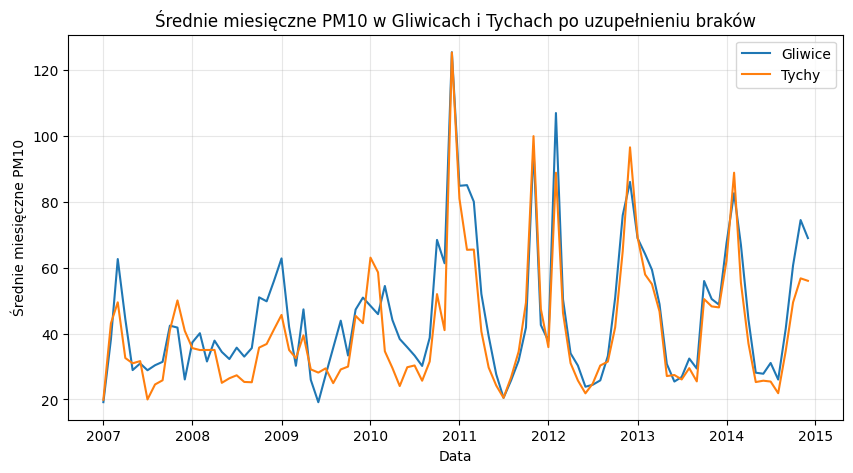

In [6]:
# Wykres średniego miesięcznego PM10 po uzupełnieniu braków

plt.figure(figsize=(10, 5))

for miasto in ["Gliwice", "Tychy"]:
    temp = pm10_month[pm10_month["Miasto"] == miasto].sort_values("Data")
    plt.plot(temp["Data"], temp["PM10"], label=miasto)

plt.title("Średnie miesięczne PM10 w Gliwicach i Tychach po uzupełnieniu braków")
plt.xlabel("Data")
plt.ylabel("Średnie miesięczne PM10")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# 2. Wczytanie i przygotowanie danych chorobowych J45
import pandas as pd
import subprocess
import io

# Eksport tabeli z bazy .mdb do DataFrame
cmd = ["mdb-export", "SUM_2015-03-19.mdb", "SUM_2007_2014"]
result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode != 0:
    print("Błąd podczas eksportu danych z pliku .mdb:")
    print(result.stderr)
else:
    df = pd.read_csv(io.StringIO(result.stdout))
    display(df.head())
    print(df.columns)

,KOD_TERYT_PACJENTA,GMINA_PACJENTA,DATA,ROZPOZNANIE,PLEC,WIEK,LB_OSOB
0,2415041,Wodzisław Śląski,09/24/07 00:00:00,J45,1.0,68.0,1
1,2469011,Katowice,02/23/07 00:00:00,J45,1.0,30.0,1
2,2475011,Sosnowiec,07/11/07 00:00:00,J45,1.0,50.0,1
3,2469011,Katowice,04/24/07 00:00:00,J44,1.0,54.0,1
4,2469011,Katowice,07/12/07 00:00:00,J45.0,2.0,51.0,1


Index(['KOD_TERYT_PACJENTA', 'GMINA_PACJENTA', 'DATA', 'ROZPOZNANIE', 'PLEC',
       'WIEK', 'LB_OSOB'],
      dtype='str')


In [8]:
# Filtrowanie danych chorobowych J45

df_j45 = df[
    df["ROZPOZNANIE"].str.startswith("J45", na=False)
].copy()

df_j45 = df_j45[
    df_j45["GMINA_PACJENTA"].isin(["Gliwice", "Tychy"])
].copy()

df_j45["DATA"] = pd.to_datetime(
    df_j45["DATA"],
    format="%m/%d/%y %H:%M:%S",
    errors="coerce"
)

df_j45["LB_OSOB"] = pd.to_numeric(df_j45["LB_OSOB"], errors="coerce")

print("Liczba rekordów po filtrowaniu:", df_j45.shape[0])
print("Braki daty po konwersji:", df_j45["DATA"].isna().sum())
print("Braki LB_OSOB:", df_j45["LB_OSOB"].isna().sum())

display(df_j45.head())

Liczba rekordów po filtrowaniu: 215482
Braki daty po konwersji: 0
Braki LB_OSOB: 0


,KOD_TERYT_PACJENTA,GMINA_PACJENTA,DATA,ROZPOZNANIE,PLEC,WIEK,LB_OSOB
8,2466011,Gliwice,2007-11-08,J45,1.0,NaN,9
17,2477011,Tychy,2007-11-30,J45,2.0,45.0,1
19,2477011,Tychy,2007-04-02,J45,1.0,49.0,2
20,2466011,Gliwice,2007-03-26,J45,2.0,42.0,1
33,2466011,Gliwice,2007-03-30,J45,2.0,46.0,2


In [9]:
# Agregacja danych J45 najpierw do poziomu dziennego, a następnie miesięcznego

j45_daily = (
    df_j45
    .dropna(subset=["DATA", "LB_OSOB"])
    .groupby(["DATA", "GMINA_PACJENTA"])["LB_OSOB"]
    .sum()
    .reset_index()
    .rename(columns={
        "DATA": "Data",
        "GMINA_PACJENTA": "Miasto",
        "LB_OSOB": "J45"
    })
)

j45_daily["Rok"] = j45_daily["Data"].dt.year
j45_daily["Miesiac"] = j45_daily["Data"].dt.month

display(j45_daily.head(10))

j45_month = (
    j45_daily
    .groupby(["Rok", "Miesiac", "Miasto"])["J45"]
    .sum()
    .reset_index()
)

display(j45_month.head(10))
print("Rozmiar miesięcznych danych J45:", j45_month.shape)

,Data,Miasto,J45,Rok,Miesiac
0,2007-01-01,Gliwice,2,2007,1
1,2007-01-02,Gliwice,82,2007,1
2,2007-01-02,Tychy,61,2007,1
3,2007-01-03,Gliwice,104,2007,1
4,2007-01-03,Tychy,57,2007,1
5,2007-01-04,Gliwice,70,2007,1
6,2007-01-04,Tychy,65,2007,1
7,2007-01-05,Gliwice,90,2007,1
8,2007-01-05,Tychy,65,2007,1
9,2007-01-06,Gliwice,2,2007,1


,Rok,Miesiac,Miasto,J45
0,2007,1,Gliwice,1941
1,2007,1,Tychy,1428
2,2007,2,Gliwice,1707
3,2007,2,Tychy,1144
4,2007,3,Gliwice,2031
5,2007,3,Tychy,1269
6,2007,4,Gliwice,1829
7,2007,4,Tychy,1268
8,2007,5,Gliwice,1810
9,2007,5,Tychy,1180


Rozmiar miesięcznych danych J45: (192, 4)


In [10]:
# Dane o liczbie mieszkańców

population_data = pd.DataFrame({
    "Rok": [
        2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
        2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014
    ],
    "Miasto": [
        "Gliwice", "Gliwice", "Gliwice", "Gliwice", "Gliwice", "Gliwice", "Gliwice", "Gliwice",
        "Tychy", "Tychy", "Tychy", "Tychy", "Tychy", "Tychy", "Tychy", "Tychy"
    ],
    "Ludnosc": [
        197393, 196668, 196167, 187830, 186868, 186210, 185450, 184415,
        129776, 129475, 129449, 129507, 129322, 129112, 128799, 128621
    ]
})

display(population_data)

,Rok,Miasto,Ludnosc
0,2007,Gliwice,197393
1,2008,Gliwice,196668
2,2009,Gliwice,196167
3,2010,Gliwice,187830
4,2011,Gliwice,186868
5,2012,Gliwice,186210
6,2013,Gliwice,185450
7,2014,Gliwice,184415
8,2007,Tychy,129776
9,2008,Tychy,129475


In [11]:
# Połączenie uzupełnionych danych PM10 z J45 i liczbą mieszkańców

pm10_for_merge = pm10_month[
    [
        "Rok", "Miesiac", "Data", "Miasto",
        "PM10",
        "PM10_przed_uzupelnieniem",
        "PM10_byl_brak",
        "PM10_metoda",
        "slaby_miesiac_PM10",
        "liczba_dni_w_miesiacu",
        "liczba_dni_z_pomiarem",
        "procent_dni_z_pomiarem"
    ]
].copy()

df_all = pm10_for_merge.merge(
    j45_month,
    on=["Rok", "Miesiac", "Miasto"],
    how="left"
)

# Jeżeli w danych J45 jakiś miesiąc nie ma rekordu, oznaczamy to i ustawiamy J45 = 0
# W Twoich danych prawdopodobnie nie powinno być takich braków, ale ten krok zabezpiecza pełny dataset.
df_all["J45_brak_po_polaczeniu"] = df_all["J45"].isna()
df_all["J45"] = df_all["J45"].fillna(0)

df_all = df_all.merge(
    population_data,
    on=["Rok", "Miasto"],
    how="left"
)

df_all["J45_na_100k"] = df_all["J45"] / df_all["Ludnosc"] * 100000

display(df_all.head(10))
print("Rozmiar finalnego zbioru:", df_all.shape)

,Rok,Miesiac,Data,Miasto,PM10,PM10_przed_uzupelnieniem,PM10_byl_brak,PM10_metoda,slaby_miesiac_PM10,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,procent_dni_z_pomiarem,J45,J45_brak_po_polaczeniu,Ludnosc,J45_na_100k
0,2007,1,2007-01-01,Gliwice,19.187994,19.187994,False,oryginalna wartość miesięczna,False,31,31,100.000000,1941,False,197393,983.317544
1,2007,2,2007-02-01,Gliwice,38.279270,38.279270,False,oryginalna wartość miesięczna,False,28,22,78.571429,1707,False,197393,864.772307
2,2007,3,2007-03-01,Gliwice,62.601449,62.601449,False,oryginalna wartość miesięczna,False,31,31,100.000000,2031,False,197393,1028.911866
3,2007,4,2007-04-01,Gliwice,44.388164,44.388164,False,oryginalna wartość miesięczna,False,30,30,100.000000,1829,False,197393,926.577943
4,2007,5,2007-05-01,Gliwice,28.912873,28.912873,False,oryginalna wartość miesięczna,False,31,31,100.000000,1810,False,197393,916.952476
5,2007,6,2007-06-01,Gliwice,30.937500,30.937500,False,oryginalna wartość miesięczna,False,30,30,100.000000,1726,False,197393,874.397775
6,2007,7,2007-07-01,Gliwice,28.869331,28.869331,False,oryginalna wartość miesięczna,False,31,31,100.000000,1403,False,197393,710.764819
7,2007,8,2007-08-01,Gliwice,30.387915,30.387915,False,oryginalna wartość miesięczna,False,31,31,100.000000,1235,False,197393,625.655418
8,2007,9,2007-09-01,Gliwice,31.425928,31.425928,False,oryginalna wartość miesięczna,False,30,30,100.000000,1618,False,197393,819.684589
9,2007,10,2007-10-01,Gliwice,42.401590,42.401590,False,oryginalna wartość miesięczna,False,31,31,100.000000,1784,False,197393,903.780782


Rozmiar finalnego zbioru: (192, 16)


In [12]:
# Finalna kontrola braków danych

print("Braki danych w df_all:")
print(df_all.isna().sum())

print("\nProcent braków danych w df_all:")
print((df_all.isna().mean() * 100).round(2))

print("\nLiczba wierszy w df_all:", df_all.shape[0])

print("\nLiczba wartości PM10 uzupełnionych:")
print(df_all["PM10_byl_brak"].sum())

print("\nMetody uzupelnienia PM10:")
display(df_all["PM10_metoda"].value_counts())

print("\nLiczba słabszych miesięcy PM10, czyli miesięcy z mniej niż 75% dni z pomiarem:")
print(df_all["slaby_miesiac_PM10"].sum())

print("\nLiczba miesięcy bez rekordu J45 po połączeniu:")
print(df_all["J45_brak_po_polaczeniu"].sum())

# Nie usuwamy obserwacji, bo PM10 zostało uzupełnione, a J45 ma wartości miesięczne
df_clean = df_all.copy()

display(df_clean.head())

Braki danych w df_all:
Rok                          0
Miesiac                      0
Data                         0
Miasto                       0
PM10                         0
PM10_przed_uzupelnieniem    10
PM10_byl_brak                0
PM10_metoda                  0
slaby_miesiac_PM10           0
liczba_dni_w_miesiacu        0
liczba_dni_z_pomiarem        0
procent_dni_z_pomiarem       0
J45                          0
J45_brak_po_polaczeniu       0
Ludnosc                      0
J45_na_100k                  0
dtype: int64

Procent braków danych w df_all:
Rok                         0.00
Miesiac                     0.00
Data                        0.00
Miasto                      0.00
PM10                        0.00
PM10_przed_uzupelnieniem    5.21
PM10_byl_brak               0.00
PM10_metoda                 0.00
slaby_miesiac_PM10          0.00
liczba_dni_w_miesiacu       0.00
liczba_dni_z_pomiarem       0.00
procent_dni_z_pomiarem      0.00
J45                         0.00
J45_br

PM10_metoda
oryginalna wartość miesięczna                       182
interpolacja liniowa krótkiej luki                    8
średnia dla tego samego miesiąca w danym mieście      2
Name: count, dtype: int64


Liczba słabszych miesięcy PM10, czyli miesięcy z mniej niż 75% dni z pomiarem:
27

Liczba miesięcy bez rekordu J45 po połączeniu:
0


,Rok,Miesiac,Data,Miasto,PM10,PM10_przed_uzupelnieniem,PM10_byl_brak,PM10_metoda,slaby_miesiac_PM10,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,procent_dni_z_pomiarem,J45,J45_brak_po_polaczeniu,Ludnosc,J45_na_100k
0,2007,1,2007-01-01,Gliwice,19.187994,19.187994,False,oryginalna wartość miesięczna,False,31,31,100.000000,1941,False,197393,983.317544
1,2007,2,2007-02-01,Gliwice,38.279270,38.279270,False,oryginalna wartość miesięczna,False,28,22,78.571429,1707,False,197393,864.772307
2,2007,3,2007-03-01,Gliwice,62.601449,62.601449,False,oryginalna wartość miesięczna,False,31,31,100.000000,2031,False,197393,1028.911866
3,2007,4,2007-04-01,Gliwice,44.388164,44.388164,False,oryginalna wartość miesięczna,False,30,30,100.000000,1829,False,197393,926.577943
4,2007,5,2007-05-01,Gliwice,28.912873,28.912873,False,oryginalna wartość miesięczna,False,31,31,100.000000,1810,False,197393,916.952476


In [13]:
# Podstawowe statystyki dla dwóch badanych cech
statystyki = df_clean[["PM10", "J45", "J45_na_100k"]].describe()

display(statystyki)
def punkt_srodkowy(series):
    return (series.min() + series.max()) / 2

podsumowanie = pd.DataFrame({
    "Średnia": [
        df_clean["PM10"].mean(),
        df_clean["J45"].mean(),
        df_clean["J45_na_100k"].mean()
    ],
    "Mediana": [
        df_clean["PM10"].median(),
        df_clean["J45"].median(),
        df_clean["J45_na_100k"].median()
    ],
    "Punkt środkowy": [
        punkt_srodkowy(df_clean["PM10"]),
        punkt_srodkowy(df_clean["J45"]),
        punkt_srodkowy(df_clean["J45_na_100k"])
    ],
    "Minimum": [
        df_clean["PM10"].min(),
        df_clean["J45"].min(),
        df_clean["J45_na_100k"].min()
    ],
    "Maksimum": [
        df_clean["PM10"].max(),
        df_clean["J45"].max(),
        df_clean["J45_na_100k"].max()
    ],
    "Odchylenie standardowe": [
        df_clean["PM10"].std(),
        df_clean["J45"].std(),
        df_clean["J45_na_100k"].std()
    ]
}, index=["PM10", "J45", "J45_na_100k"])

display(podsumowanie)

,PM10,J45,J45_na_100k
count,192.000000,192.000000,192.000000
mean,43.143359,1406.557292,894.030323
std,19.727811,273.960189,159.692474
min,19.170057,645.000000,500.780286
25%,29.428289,1225.000000,790.214401
50%,36.902282,1411.500000,885.909972
75%,50.462604,1600.000000,1007.796948
max,125.336831,2031.000000,1337.746091


,Średnia,Mediana,Punkt środkowy,Minimum,Maksimum,Odchylenie standardowe
PM10,43.143359,36.902282,72.253444,19.170057,125.336831,19.727811
J45,1406.557292,1411.500000,1338.000000,645.000000,2031.000000,273.960189
J45_na_100k,894.030323,885.909972,919.263188,500.780286,1337.746091,159.692474


In [14]:
# Statystyki z podziałem na miasta
statystyki_miasta = df_clean.groupby("Miasto")[["PM10", "J45", "J45_na_100k"]].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

display(statystyki_miasta)

PM10                                                           J45  \
        count       mean     median        min         max        std count   
Miasto                                                                        
Gliwice    96  45.397698  39.654329  19.170057  125.336831  20.100107    96   
Tychy      96  40.889021  35.008333  19.922421  125.251120  19.188130    96   

                                                    J45_na_100k              \
                mean  median  min   max         std       count        mean   
Miasto                                                                        
Gliwice  1568.041667  1594.0  985  2031  227.634098          96  824.785875   
Tychy    1245.072917  1271.0  645  1730  215.354897          96  963.274772   

                                                          
             median         min          max         std  
Miasto                                                    
Gliwice  840.518802  530.843859  1028.911866  117.285260  
Tychy    983.100224  500.780286  1337.746091  166.809618

In [15]:
# Średnie wartości PM10 i J45 dla każdego miasta
mean_values = df_clean.groupby("Miasto")[["PM10", "J45", "J45_na_100k"]].mean()

display(mean_values)

,PM10,J45,J45_na_100k
Miasto,,,
Gliwice,45.397698,1568.041667,824.785875
Tychy,40.889021,1245.072917,963.274772


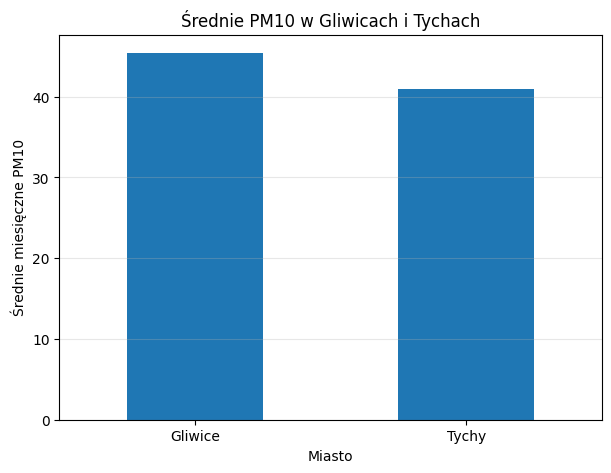

In [16]:
# Wykres słupkowy średnich wartości PM10
plt.figure(figsize=(7, 5))
mean_values["PM10"].plot(kind="bar")
plt.title("Średnie PM10 w Gliwicach i Tychach")
plt.xlabel("Miasto")
plt.ylabel("Średnie miesięczne PM10")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

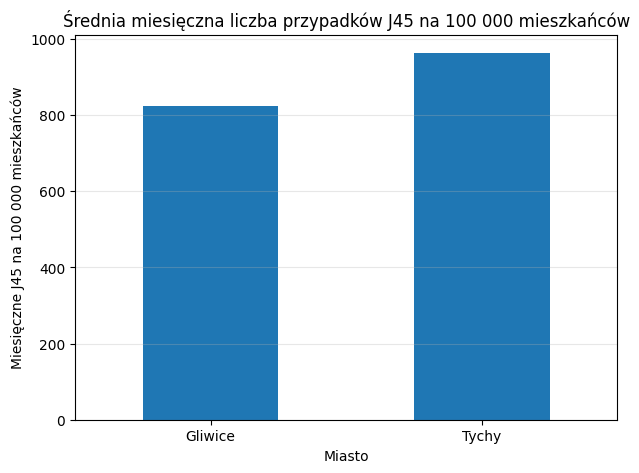

In [17]:
# Wykres słupkowy średnich wartości J45
plt.figure(figsize=(7, 5))
mean_values["J45_na_100k"].plot(kind="bar")
plt.title("Średnia miesięczna liczba przypadków J45 na 100 000 mieszkańców")
plt.xlabel("Miasto")
plt.ylabel("Miesięczne J45 na 100 000 mieszkańców")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

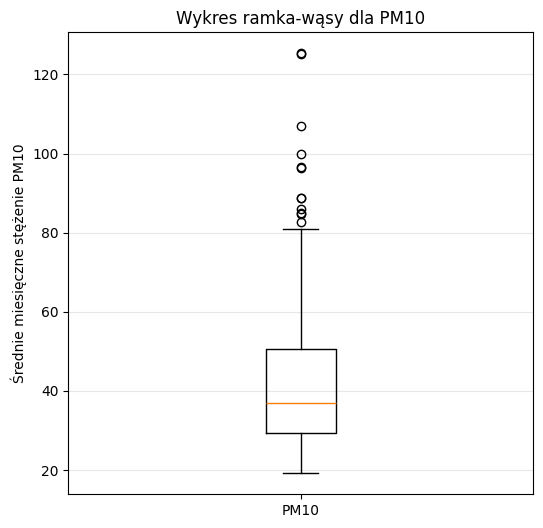

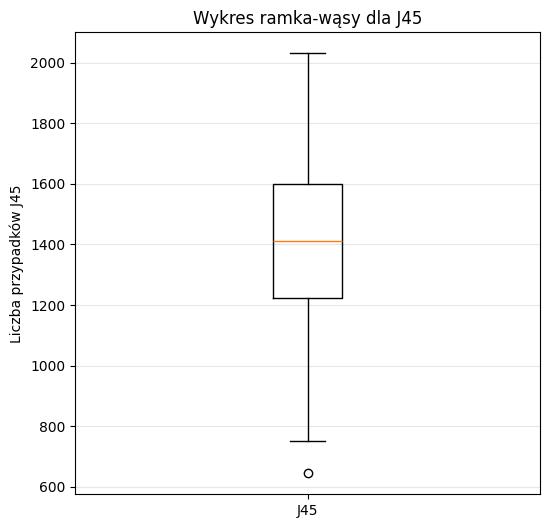

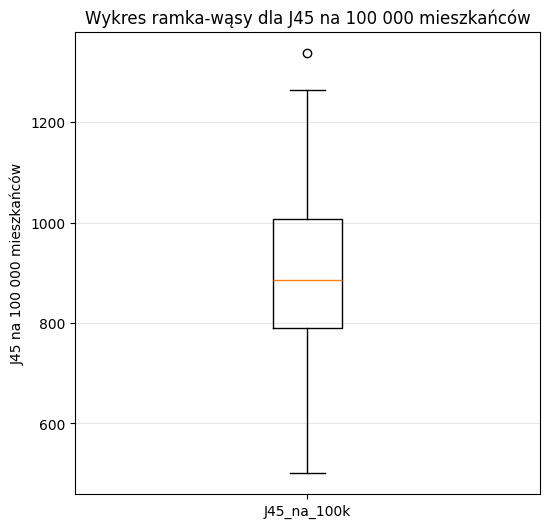

In [18]:
# Boxploty dla PM10 i J45
import matplotlib.pyplot as plt

# upewniamy się, że PM10 i J45 są liczbami i nie mają braków
pm10_values = df_clean["PM10"].dropna()
j45_values = df_clean["J45"].dropna()
j45_rate_values = df_clean["J45_na_100k"].dropna()

plt.figure(figsize=(6, 6))
plt.boxplot(pm10_values, vert=True, tick_labels=["PM10"])
plt.title("Wykres ramka-wąsy dla PM10")
plt.ylabel("Średnie miesięczne stężenie PM10")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.boxplot(j45_values, vert=True, tick_labels=["J45"])
plt.title("Wykres ramka-wąsy dla J45")
plt.ylabel("Liczba przypadków J45")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.boxplot(j45_rate_values, vert=True, tick_labels=["J45_na_100k"])
plt.title("Wykres ramka-wąsy dla J45 na 100 000 mieszkańców")
plt.ylabel("J45 na 100 000 mieszkańców")
plt.grid(axis="y", alpha=0.3)
plt.show()

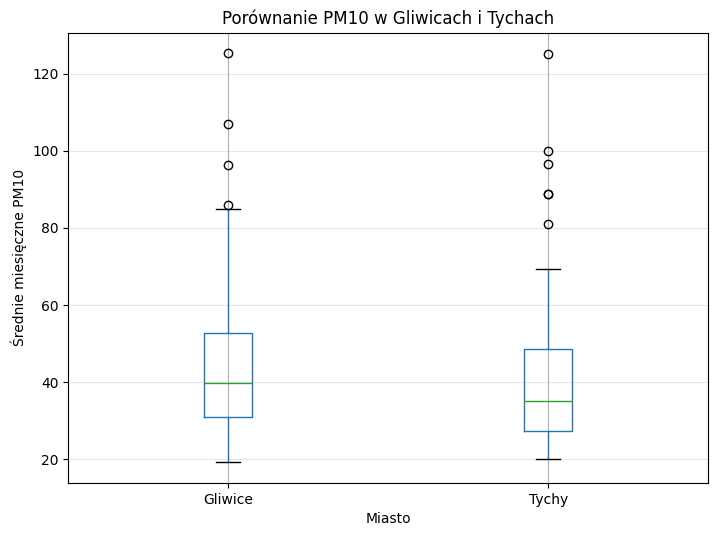

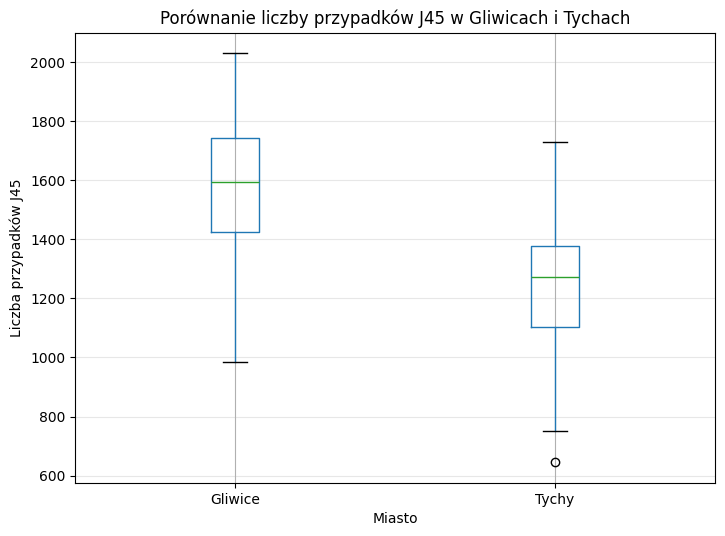

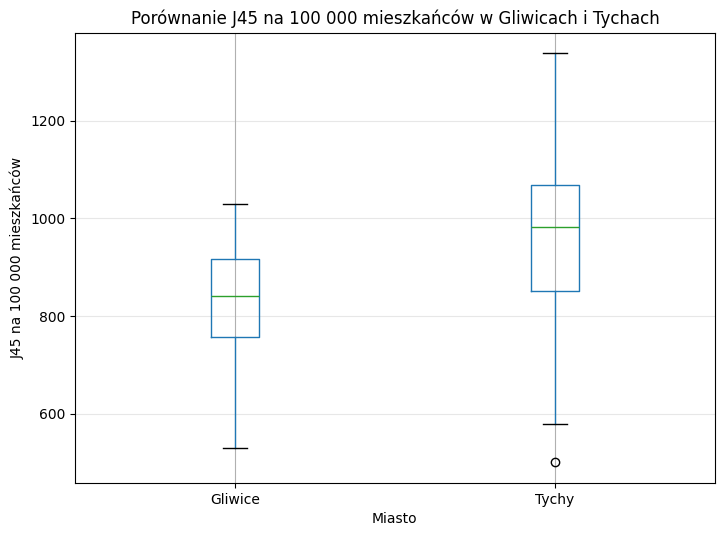

In [19]:
# Boxplot z podziałem na miasta
ax = df_clean.boxplot(column="PM10", by="Miasto", figsize=(8, 6))
plt.title("Porównanie PM10 w Gliwicach i Tychach")
plt.suptitle("")
plt.xlabel("Miasto")
plt.ylabel("Średnie miesięczne PM10")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Dla J45
ax = df_clean.boxplot(column="J45", by="Miasto", figsize=(8, 6))
plt.title("Porównanie liczby przypadków J45 w Gliwicach i Tychach")
plt.suptitle("")
plt.xlabel("Miasto")
plt.ylabel("Liczba przypadków J45")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Dla J45 na 100 000 mieszkańców
ax = df_clean.boxplot(column="J45_na_100k", by="Miasto", figsize=(8, 6))
plt.title("Porównanie J45 na 100 000 mieszkańców w Gliwicach i Tychach")
plt.suptitle("")
plt.xlabel("Miasto")
plt.ylabel("J45 na 100 000 mieszkańców")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [20]:
# Outliery dla PM10 i J45
def znajdz_outliery_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    dolna_granica = Q1 - 1.5 * IQR
    gorna_granica = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < dolna_granica) | (df[column] > gorna_granica)]
    
    print(f"Zmienna: {column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Dolna granica:", dolna_granica)
    print("Górna granica:", gorna_granica)
    print("Liczba outlierów:", len(outliers))
    
    return outliers

outliers_pm10 = znajdz_outliery_iqr(df_clean, "PM10")
display(outliers_pm10)

outliers_j45 = znajdz_outliery_iqr(df_clean, "J45")
display(outliers_j45)

outliers_j45_rate = znajdz_outliery_iqr(df_clean, "J45_na_100k")
display(outliers_j45_rate)

Zmienna: PM10
Q1: 29.42828914645593
Q3: 50.462603514375864
IQR: 21.034314367919933
Dolna granica: -2.123182405423968
Górna granica: 82.01407506625577
Liczba outlierów: 12


,Rok,Miesiac,Data,Miasto,PM10,PM10_przed_uzupelnieniem,PM10_byl_brak,PM10_metoda,slaby_miesiac_PM10,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,procent_dni_z_pomiarem,J45,J45_brak_po_polaczeniu,Ludnosc,J45_na_100k
47,2010,12,2010-12-01,Gliwice,125.336831,125.336831,False,oryginalna wartość miesięczna,False,31,31,100.000000,1457,False,187830,775.701432
48,2011,1,2011-01-01,Gliwice,84.818579,84.818579,False,oryginalna wartość miesięczna,False,31,30,96.774194,1580,False,186868,845.516621
49,2011,2,2011-02-01,Gliwice,85.020880,85.020880,False,oryginalna wartość miesięczna,False,28,28,100.000000,1585,False,186868,848.192307
58,2011,11,2011-11-01,Gliwice,96.300522,96.300522,False,oryginalna wartość miesięczna,False,30,30,100.000000,1882,False,186868,1007.128026
61,2012,2,2012-02-01,Gliwice,106.891304,106.891304,False,oryginalna wartość miesięczna,False,29,24,82.758621,1549,False,186210,831.856506
71,2012,12,2012-12-01,Gliwice,86.001651,86.001651,False,oryginalna wartość miesięczna,False,31,28,90.322581,1154,False,186210,619.730412
85,2014,2,2014-02-01,Gliwice,82.573993,82.573993,False,oryginalna wartość miesięczna,False,28,28,100.000000,1532,False,184415,830.735027
143,2010,12,2010-12-01,Tychy,125.251120,125.251120,False,oryginalna wartość miesięczna,False,31,27,87.096774,1312,False,129507,1013.072652
154,2011,11,2011-11-01,Tychy,99.882126,99.882126,False,oryginalna wartość miesięczna,False,30,30,100.000000,1532,False,129322,1184.639891
157,2012,2,2012-02-01,Tychy,88.788793,88.788793,False,oryginalna wartość miesięczna,False,29,29,100.000000,1418,False,129112,1098.271268


Zmienna: J45
Q1: 1225.0
Q3: 1600.0
IQR: 375.0
Dolna granica: 662.5
Górna granica: 2162.5
Liczba outlierów: 1


,Rok,Miesiac,Data,Miasto,PM10,PM10_przed_uzupelnieniem,PM10_byl_brak,PM10_metoda,slaby_miesiac_PM10,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,procent_dni_z_pomiarem,J45,J45_brak_po_polaczeniu,Ludnosc,J45_na_100k
179,2013,12,2013-12-01,Tychy,47.929874,47.929874,False,oryginalna wartość miesięczna,False,31,31,100.0,645,False,128799,500.780286


Zmienna: J45_na_100k
Q1: 790.2144005050945
Q3: 1007.7969475779695
IQR: 217.58254707287495
Dolna granica: 463.8405798957821
Górna granica: 1334.170768187282
Liczba outlierów: 1


,Rok,Miesiac,Data,Miasto,PM10,PM10_przed_uzupelnieniem,PM10_byl_brak,PM10_metoda,slaby_miesiac_PM10,liczba_dni_w_miesiacu,liczba_dni_z_pomiarem,procent_dni_z_pomiarem,J45,J45_brak_po_polaczeniu,Ludnosc,J45_na_100k
146,2011,3,2011-03-01,Tychy,65.47791,65.47791,False,oryginalna wartość miesięczna,False,31,31,100.0,1730,False,129322,1337.746091


In [21]:
# Sprawdzenie wpływu outlierów na średnią
# PM10 bez outlierów
Q1_pm10 = df_clean["PM10"].quantile(0.25)
Q3_pm10 = df_clean["PM10"].quantile(0.75)
IQR_pm10 = Q3_pm10 - Q1_pm10

df_pm10_no_outliers = df_clean[
    (df_clean["PM10"] >= Q1_pm10 - 1.5 * IQR_pm10) &
    (df_clean["PM10"] <= Q3_pm10 + 1.5 * IQR_pm10)
]

print("PM10 - średnia z outlierami:", df_clean["PM10"].mean())
print("PM10 - średnia bez outlierów:", df_pm10_no_outliers["PM10"].mean())

print("PM10 - mediana z outlierami:", df_clean["PM10"].median())
print("PM10 - mediana bez outlierów:", df_pm10_no_outliers["PM10"].median())

PM10 - średnia z outlierami: 43.14335949293989
PM10 - średnia bez outlierów: 39.54101301495195
PM10 - mediana z outlierami: 36.90228174606428
PM10 - mediana bez outlierów: 35.6289301996614


# II. Testy parametryczne i nieparametryczne

W tej części przeprowadzono testy statystyczne dla dwóch badanych cech: średniego miesięcznego stężenia PM10 oraz miesięcznej liczby przypadków J45. Analiza obejmuje sprawdzenie normalności rozkładu, porównanie wartości między Gliwicami i Tychami za pomocą testów parametrycznych i nieparametrycznych, test chi-kwadrat oraz wyznaczenie przedziałów ufności dla średniej.

In [22]:
# Przygotowanie danych do testów statystycznych

from scipy.stats import shapiro, ttest_ind, mannwhitneyu, ttest_rel, wilcoxon, chisquare
import scipy.stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Podział danych na miasta
gliwice_data = df_clean[df_clean["Miasto"] == "Gliwice"].copy()
tychy_data = df_clean[df_clean["Miasto"] == "Tychy"].copy()

# Zmienne do testów
gliwice_pm10 = gliwice_data["PM10"].dropna()
tychy_pm10 = tychy_data["PM10"].dropna()

gliwice_j45_rate = gliwice_data["J45_na_100k"].dropna()
tychy_j45_rate = tychy_data["J45_na_100k"].dropna()

print("Liczba obserwacji PM10 - Gliwice:", len(gliwice_pm10))
print("Liczba obserwacji PM10 - Tychy:", len(tychy_pm10))
print("Liczba obserwacji J45 na 100 000 mieszkańców - Gliwice:", len(gliwice_j45_rate))
print("Liczba obserwacji J45 na 100 000 mieszkańców - Tychy:", len(tychy_j45_rate))

Liczba obserwacji PM10 - Gliwice: 96
Liczba obserwacji PM10 - Tychy: 96
Liczba obserwacji J45 na 100 000 mieszkańców - Gliwice: 96
Liczba obserwacji J45 na 100 000 mieszkańców - Tychy: 96


Test Shapiro-Wilka wykorzystano do sprawdzenia, czy rozkład badanych zmiennych jest zbliżony do rozkładu normalnego.

Hipotezy:
- H0: badana zmienna ma rozkład normalny.
- H1: badana zmienna nie ma rozkładu normalnego.

Przyjęto poziom istotności α = 0,05. Jeżeli p-value jest mniejsze lub równe 0,05, odrzuca się hipotezę zerową i uznaje, że rozkład istotnie odbiega od normalnego.

In [23]:
# Test normalności Shapiro-Wilka

# Jeżeli p-value > 0,05, nie ma podstaw do odrzucenia H0.
# Jeżeli p-value ≤ 0,05, odrzucamy H0 i uznajemy, że rozkład odbiega od normalnego.
alpha = 0.05

variables = {
    "PM10 Gliwice": gliwice_pm10,
    "PM10 Tychy": tychy_pm10,
    "J45 na 100k Gliwice": gliwice_j45_rate,
    "J45 na 100k Tychy": tychy_j45_rate
}

for name, data in variables.items():
    stat, p = shapiro(data)
    print(f"{name}: statystyka = {stat:.4f}, p-value = {p:.4f}")
    
    if p > alpha:
        print("Brak podstaw do odrzucenia H0 - rozkład można uznać za zbliżony do normalnego.\n")
    else:
        print("Odrzucamy H0 - rozkład istotnie odbiega od normalnego.\n")

PM10 Gliwice: statystyka = 0.8782, p-value = 0.0000
Odrzucamy H0 - rozkład istotnie odbiega od normalnego.

PM10 Tychy: statystyka = 0.8178, p-value = 0.0000
Odrzucamy H0 - rozkład istotnie odbiega od normalnego.

J45 na 100k Gliwice: statystyka = 0.9717, p-value = 0.0360
Odrzucamy H0 - rozkład istotnie odbiega od normalnego.

J45 na 100k Tychy: statystyka = 0.9826, p-value = 0.2330
Brak podstaw do odrzucenia H0 - rozkład można uznać za zbliżony do normalnego.



Interpretacja:
Dla zmiennej PM10 w obu miastach p-value jest mniejsze od 0,05, dlatego odrzucono hipotezę o normalności rozkładu. Oznacza to, że rozkład PM10 istotnie odbiega od normalnego. Dla zmiennej J45 w Gliwicach i Tychach p-value jest większe od 0,05, dlatego nie ma podstaw do odrzucenia hipotezy o normalności rozkładu.

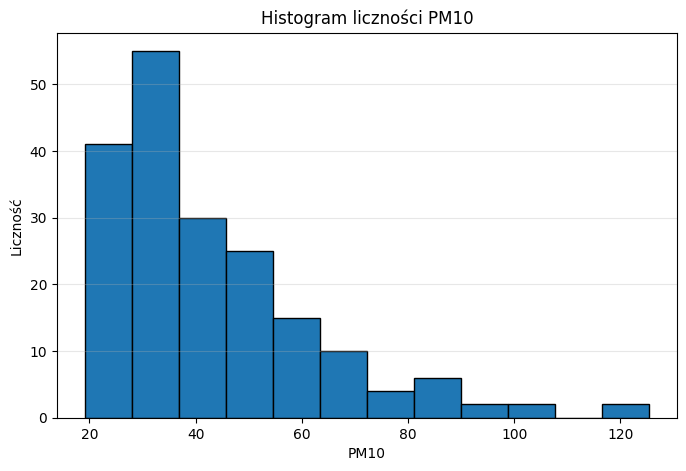

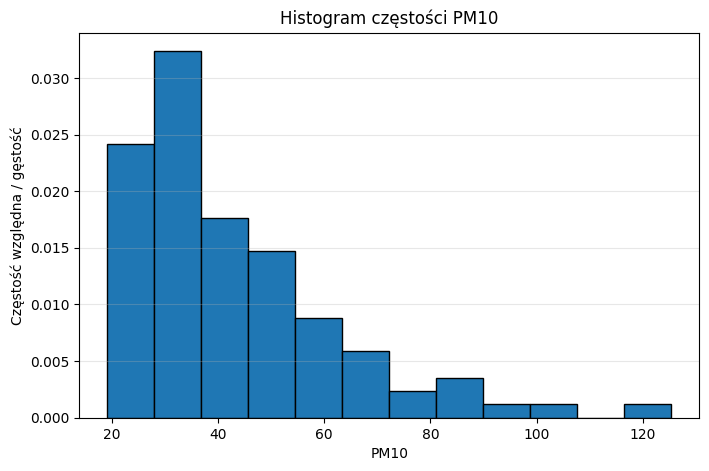

In [24]:
# Histogram liczności i częstości PM10

plt.figure(figsize=(8, 5))
plt.hist(df_clean["PM10"], bins=12, edgecolor="black")
plt.title("Histogram liczności PM10")
plt.xlabel("PM10")
plt.ylabel("Liczność")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_clean["PM10"], bins=12, density=True, edgecolor="black")
plt.title("Histogram częstości PM10")
plt.xlabel("PM10")
plt.ylabel("Częstość względna / gęstość")
plt.grid(axis="y", alpha=0.3)
plt.show()

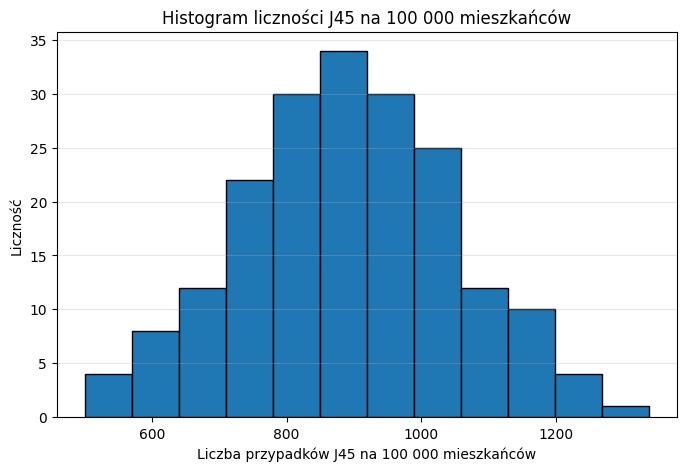

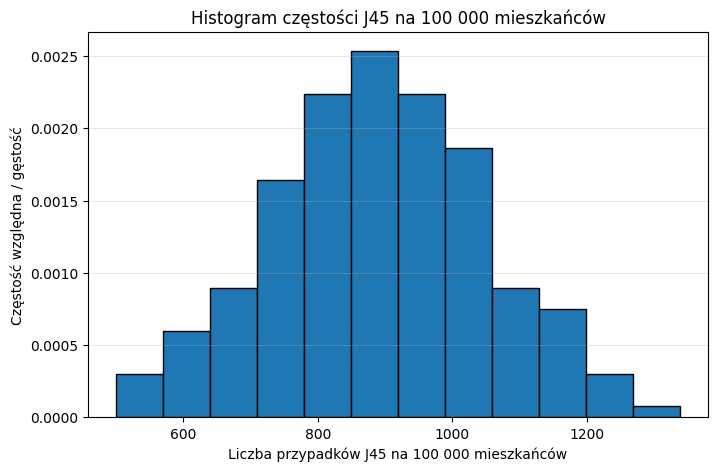

In [25]:
# Histogram liczności i częstości J45

plt.figure(figsize=(8, 5))
plt.hist(df_clean["J45_na_100k"], bins=12, edgecolor="black")
plt.title("Histogram liczności J45 na 100 000 mieszkańców")
plt.xlabel("Liczba przypadków J45 na 100 000 mieszkańców")
plt.ylabel("Liczność")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_clean["J45_na_100k"], bins=12, density=True, edgecolor="black")
plt.title("Histogram częstości J45 na 100 000 mieszkańców")
plt.xlabel("Liczba przypadków J45 na 100 000 mieszkańców")
plt.ylabel("Częstość względna / gęstość")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. Test Welcha dla prób niezależnych

Test Welcha jest parametrycznym testem istotności różnic średnich dla dwóch niezależnych grup. W tym przypadku grupami są dwa miasta: Gliwice i Tychy. Test Welcha wybrano zamiast klasycznego testu t-Studenta, ponieważ nie wymaga założenia równości wariancji w porównywanych grupach.

Hipotezy dla PM10:
- H0: średnie stężenie PM10 w Gliwicach i Tychach jest takie samo.
- H1: średnie stężenie PM10 w Gliwicach i Tychach różni się.

Analogicznie dla J45:
- H0: średnia liczba przypadków J45 w Gliwicach i Tychach jest taka sama.
- H1: średnia liczba przypadków J45 w Gliwicach i Tychach różni się.

In [26]:
# Test Welcha dla PM10 - próby niezależne

t_stat, p_value = ttest_ind(gliwice_pm10, tychy_pm10, equal_var=False)

print("Test Welcha dla PM10")
print("t-statystyka:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - średnie PM10 w Gliwicach i Tychach różnią się istotnie.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy średnich PM10.")

Test Welcha dla PM10
t-statystyka: 1.5897184017335346
p-value: 0.11356442600672077
Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy średnich PM10.


In [27]:
t_stat, p_value = ttest_ind(gliwice_j45_rate, tychy_j45_rate, equal_var=False)

print("Test Welcha dla J45 na 100 000 mieszkańców")
print("t-statystyka:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - średnia liczba przypadków J45 na 100 000 mieszkańców różni się istotnie między miastami.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy średnich J45 na 100 000 mieszkańców.")

Test Welcha dla J45 na 100 000 mieszkańców
t-statystyka: -6.654288708738778
p-value: 3.726785808091654e-10
Odrzucamy H0 - średnia liczba przypadków J45 na 100 000 mieszkańców różni się istotnie między miastami.


Interpretacja:
Dla PM10 wartość p-value wyniosła około 0,108, czyli była większa od 0,05. Nie ma więc podstaw do odrzucenia hipotezy zerowej. Oznacza to, że na podstawie testu Welcha nie wykazano istotnej statystycznie różnicy średniego PM10 między Gliwicami i Tychami.

Dla J45 wartość p-value była znacznie mniejsza od 0,05, dlatego odrzucono hipotezę zerową. Oznacza to, że średnia miesięczna liczba przypadków J45 różni się istotnie między Gliwicami i Tychami.

## 5. Test Manna-Whitneya dla prób niezależnych

Test Manna-Whitneya jest nieparametryczną alternatywą dla testu t-Studenta/Welcha. Nie wymaga założenia normalności rozkładu, dlatego jest szczególnie przydatny w przypadku zmiennej PM10, dla której test Shapiro-Wilka wykazał brak normalności rozkładu.

Hipotezy:
- H0: rozkłady wartości w Gliwicach i Tychach nie różnią się istotnie.
- H1: rozkłady wartości w Gliwicach i Tychach różnią się istotnie.

In [28]:
# Test Manna-Whitneya dla PM10

stat, p_value = mannwhitneyu(gliwice_pm10, tychy_pm10, alternative="two-sided")

print("Test Manna-Whitneya dla PM10")
print("statystyka:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - rozkłady PM10 w miastach różnią się istotnie.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy rozkładów PM10.")

Test Manna-Whitneya dla PM10
statystyka: 5421.0
p-value: 0.03482419796207767
Odrzucamy H0 - rozkłady PM10 w miastach różnią się istotnie.


In [29]:
stat, p_value = mannwhitneyu(gliwice_j45_rate, tychy_j45_rate, alternative="two-sided")

print("Test Manna-Whitneya dla J45 na 100 000 mieszkańców")
print("statystyka:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - rozkłady J45 na 100 000 mieszkańców różnią się istotnie między miastami.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy rozkładów J45 na 100 000 mieszkańców.")

Test Manna-Whitneya dla J45 na 100 000 mieszkańców
statystyka: 2220.0
p-value: 5.59916696927221e-10
Odrzucamy H0 - rozkłady J45 na 100 000 mieszkańców różnią się istotnie między miastami.


Interpretacja:
Dla PM10 test Manna-Whitneya dał p-value około 0,042, czyli poniżej 0,05. Odrzucono hipotezę zerową, co wskazuje na istotną statystycznie różnicę rozkładów PM10 między Gliwicami i Tychami. Wynik ten różni się od testu Welcha, co może wynikać z nienormalnego rozkładu PM10 oraz obecności wartości odstających.

Dla J45 p-value było znacznie mniejsze od 0,05, dlatego również odrzucono hipotezę zerową. Oznacza to, że rozkłady miesięcznej liczby przypadków J45 różnią się istotnie między miastami.

## 6. Testy dla prób zależnych

Oprócz testów dla prób niezależnych wykonano również testy dla prób zależnych. Dane potraktowano jako sparowane, ponieważ dla każdego miesiąca można zestawić wartość z Gliwic z wartością z Tychów. Porównywane są więc obserwacje z tych samych miesięcy i lat.

Przykład pary obserwacji: PM10 w Gliwicach w styczniu 2007 roku oraz PM10 w Tychach w styczniu 2007 roku.

In [30]:
# Przygotowanie danych sparowanych: Gliwice vs Tychy miesiąc po miesiącu

paired_pm10 = df_clean.pivot_table(
    index=["Rok", "Miesiac"],
    columns="Miasto",
    values="PM10"
).dropna()

display(paired_pm10.head())
print(paired_pm10.shape)

Miasto          Gliwice      Tychy
Rok  Miesiac                      
2007 1        19.187994  19.922421
     2        38.279270  43.105945
     3        62.601449  49.478103
     4        44.388164  32.577778
     5        28.912873  30.971774

(96, 2)


In [31]:
# Test t dla prób zależnych - PM10

t_stat, p_value = ttest_rel(paired_pm10["Gliwice"], paired_pm10["Tychy"])

print("Test t dla prób zależnych PM10")
print("t-statystyka:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - średnie PM10 różni się istotnie między miastami w tych samych miesiącach.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy PM10 w tych samych miesiącach.")

Test t dla prób zależnych PM10
t-statystyka: 5.802835944427436
p-value: 8.559206073820635e-08
Odrzucamy H0 - średnie PM10 różni się istotnie między miastami w tych samych miesiącach.


In [32]:
# Test Wilcoxona dla prób zależnych - PM10

stat, p_value = wilcoxon(paired_pm10["Gliwice"], paired_pm10["Tychy"])

print("Test Wilcoxona dla prób zależnych PM10")
print("statystyka:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - PM10 różni się istotnie między miastami w tych samych miesiącach.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy PM10 w tych samych miesiącach.")

Test Wilcoxona dla prób zależnych PM10
statystyka: 909.0
p-value: 2.1547419395737723e-07
Odrzucamy H0 - PM10 różni się istotnie między miastami w tych samych miesiącach.


In [59]:
from scipy.stats import ttest_rel, wilcoxon, shapiro

paired_j45 = df_clean.pivot_table(
    index=["Rok", "Miesiac"],
    columns="Miasto",
    values="J45_na_100k"
).dropna()

diff_j45 = paired_j45["Gliwice"] - paired_j45["Tychy"]

print("Shapiro dla różnic J45_na_100k:")
print(shapiro(diff_j45))

print("Test t dla prób zależnych J45_na_100k:")
print(ttest_rel(paired_j45["Gliwice"], paired_j45["Tychy"]))

print("Test Wilcoxona dla J45_na_100k:")
print(wilcoxon(paired_j45["Gliwice"], paired_j45["Tychy"]))

Shapiro dla różnic J45_na_100k:
ShapiroResult(statistic=np.float64(0.9923536342994626), pvalue=np.float64(0.8628816594976113))
Test t dla prób zależnych J45_na_100k:
TtestResult(statistic=np.float64(-12.302015889681504), pvalue=np.float64(2.2853591243280584e-21), df=np.int64(95))
Test Wilcoxona dla J45_na_100k:
WilcoxonResult(statistic=np.float64(186.0), pvalue=np.float64(4.97533081737759e-15))


In [33]:
paired_j45_rate = df_clean.pivot_table(
    index=["Rok", "Miesiac"],
    columns="Miasto",
    values="J45_na_100k"
).dropna()

display(paired_j45_rate.head())
print(paired_j45_rate.shape)

Miasto            Gliwice        Tychy
Rok  Miesiac                          
2007 1         983.317544  1100.357539
     2         864.772307   881.518925
     3        1028.911866   977.838738
     4         926.577943   977.068179
     5         916.952476   909.259031

(96, 2)


In [34]:
# Test t dla prób zależnych - J45

t_stat, p_value = ttest_rel(paired_j45_rate["Gliwice"], paired_j45_rate["Tychy"])

print("Test t dla prób zależnych - J45 na 100 000 mieszkańców")
print("t-statystyka:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - liczba przypadków J45 różni się istotnie między miastami w tych samych miesiącach.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy J45 w tych samych miesiącach.")

Test t dla prób zależnych - J45 na 100 000 mieszkańców
t-statystyka: -12.302015889681504
p-value: 2.2853591243280584e-21
Odrzucamy H0 - liczba przypadków J45 różni się istotnie między miastami w tych samych miesiącach.


In [35]:
# Test Wilcoxona dla prób zależnych - J45

stat, p_value = wilcoxon(paired_j45_rate["Gliwice"], paired_j45_rate["Tychy"])

print("Test Wilcoxona dla prób zależnych - J45 na 100 000 mieszkańców")
print("statystyka:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - J45 różni się istotnie między miastami w tych samych miesiącach.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnej różnicy J45 w tych samych miesiącach.")

Test Wilcoxona dla prób zależnych - J45 na 100 000 mieszkańców
statystyka: 186.0
p-value: 4.97533081737759e-15
Odrzucamy H0 - J45 różni się istotnie między miastami w tych samych miesiącach.


Test chi-kwadrat

In [36]:
# Kategoryzacja PM10

df_clean["Kategoria_PM10"] = pd.cut(
    df_clean["PM10"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["bardzo niskie", "umiarkowane", "wysokie", "bardzo wysokie"]
)

pm10_counts = df_clean["Kategoria_PM10"].value_counts().sort_index()

display(pm10_counts)

Kategoria_PM10
bardzo niskie       3
umiarkowane       138
wysokie            48
bardzo wysokie      3
Name: count, dtype: int64

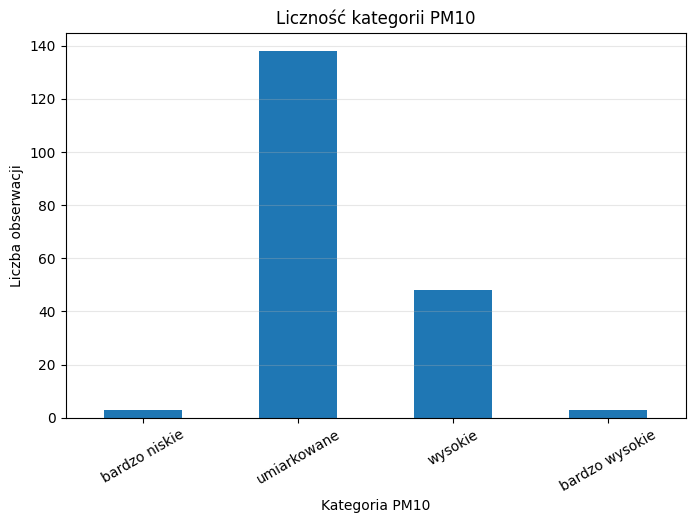

In [37]:
plt.figure(figsize=(8, 5))
pm10_counts.plot(kind="bar")
plt.title("Liczność kategorii PM10")
plt.xlabel("Kategoria PM10")
plt.ylabel("Liczba obserwacji")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [38]:
# H0: obserwacje są równomiernie rozłożone między kategoriami PM10.
# H1: obserwacje nie są równomiernie rozłożone między kategoriami PM10.
chi_stat, p_value = chisquare(pm10_counts)

print("Test chi-kwadrat dla kategorii PM10")
print("chi2:", chi_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Odrzucamy H0 - obserwacje nie są równomiernie rozłożone między kategoriami PM10.")
else:
    print("Brak podstaw do odrzucenia H0 - nie wykazano istotnych różnic liczności między kategoriami PM10.")

Test chi-kwadrat dla kategorii PM10
chi2: 253.125
p-value: 1.3801233188735384e-54
Odrzucamy H0 - obserwacje nie są równomiernie rozłożone między kategoriami PM10.


In [39]:
# 95% przedział ufności dla średniego PM10

pm10 = df_clean["PM10"].dropna()

mean_pm10 = pm10.mean()
sem_pm10 = st.sem(pm10)

ci_pm10 = st.t.interval(
    confidence=0.95,
    df=len(pm10)-1,
    loc=mean_pm10,
    scale=sem_pm10
)

print("Średnia PM10:", mean_pm10)
print(f"95% przedział ufności dla średniej PM10: ({ci_pm10[0]:.2f}, {ci_pm10[1]:.2f})")

Średnia PM10: 43.14335949293989
95% przedział ufności dla średniej PM10: (40.34, 45.95)


In [40]:
j45_rate = df_clean["J45_na_100k"].dropna()

mean_j45_rate = j45_rate.mean()
sem_j45_rate = st.sem(j45_rate)

ci_j45_rate = st.t.interval(
    confidence=0.95,
    df=len(j45_rate)-1,
    loc=mean_j45_rate,
    scale=sem_j45_rate
)

print(f"Średnia J45 na 100 000 mieszkańców: {mean_j45_rate:.2f}")
print(f"95% przedział ufności dla średniej J45 na 100 000 mieszkańców: ({ci_j45_rate[0]:.2f}, {ci_j45_rate[1]:.2f})")

Średnia J45 na 100 000 mieszkańców: 894.03
95% przedział ufności dla średniej J45 na 100 000 mieszkańców: (871.30, 916.76)


# III. Korelacja i regresja

In [41]:
# Przygotowanie danych do korelacji i regresji

corr_data = df_clean[["PM10", "J45_na_100k", "Miasto", "Rok", "Miesiac", "Data"]].copy()

corr_data["PM10"] = pd.to_numeric(corr_data["PM10"], errors="coerce")
corr_data["J45_na_100k"] = pd.to_numeric(corr_data["J45_na_100k"], errors="coerce")

corr_data = corr_data.dropna(subset=["PM10", "J45_na_100k"])

display(corr_data.head())
print(corr_data.shape)

,PM10,J45_na_100k,Miasto,Rok,Miesiac,Data
0,19.187994,983.317544,Gliwice,2007,1,2007-01-01
1,38.279270,864.772307,Gliwice,2007,2,2007-02-01
2,62.601449,1028.911866,Gliwice,2007,3,2007-03-01
3,44.388164,926.577943,Gliwice,2007,4,2007-04-01
4,28.912873,916.952476,Gliwice,2007,5,2007-05-01


(192, 6)


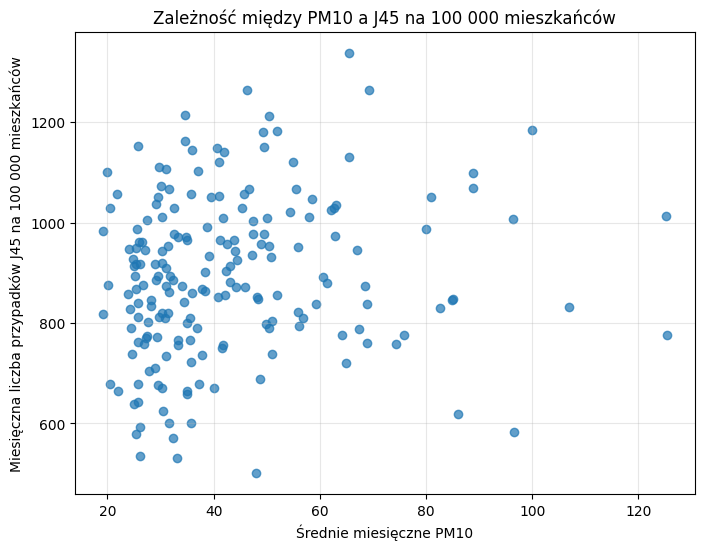

In [42]:
# Wykres punktowy PM10 vs J45
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(corr_data["PM10"], corr_data["J45_na_100k"], alpha=0.7)
plt.title("Zależność między PM10 a J45 na 100 000 mieszkańców")
plt.xlabel("Średnie miesięczne PM10")
plt.ylabel("Miesięczna liczba przypadków J45 na 100 000 mieszkańców")
plt.grid(alpha=0.3)
plt.show()

In [43]:
# Korelacja Pearsona
# H0: Nie istnieje istotna liniowa zależność między PM10 a liczbą przypadków J45.
# H1: Istnieje istotna liniowa zależność między PM10 a liczbą przypadków J45.
from scipy.stats import pearsonr

pearson_corr, pearson_p = pearsonr(corr_data["PM10"], corr_data["J45_na_100k"])

print("Korelacja Pearsona PM10 vs J45 na 100 000 mieszkańców")
print("r =", pearson_corr)
print("p-value =", pearson_p)

if pearson_p < 0.05:
    print("Korelacja Pearsona jest istotna statystycznie.")
else:
    print("Brak podstaw do uznania korelacji Pearsona za istotną statystycznie.")

Korelacja Pearsona PM10 vs J45 na 100 000 mieszkańców
r = 0.14720965604881123
p-value = 0.04159081370273884
Korelacja Pearsona jest istotna statystycznie.


In [44]:
# Interpretacja kierunku
if pearson_corr > 0:
    print("Kierunek zależności: dodatni - wraz ze wzrostem PM10 rośnie J45.")
elif pearson_corr < 0:
    print("Kierunek zależności: ujemny - wraz ze wzrostem PM10 maleje J45.")
else:
    print("Brak zależności liniowej.")

Kierunek zależności: dodatni - wraz ze wzrostem PM10 rośnie J45.


In [45]:
# Korelacja Spearmana
# H0: Nie istnieje istotna monotoniczna zależność między PM10 a liczbą przypadków J45.
# H1: Istnieje istotna monotoniczna zależność między PM10 a liczbą przypadków J45.
from scipy.stats import spearmanr

spearman_corr, spearman_p = spearmanr(corr_data["PM10"], corr_data["J45_na_100k"])

print("Korelacja Spearmana PM10 vs J45 na 100 000 mieszkańców")
print("rho =", spearman_corr)
print("p-value =", spearman_p)

if spearman_p < 0.05:
    print("Korelacja Spearmana jest istotna statystycznie.")
else:
    print("Brak podstaw do uznania korelacji Spearmana za istotną statystycznie.")

Korelacja Spearmana PM10 vs J45 na 100 000 mieszkańców
rho = 0.18602494371049563
p-value = 0.009783330974260285
Korelacja Spearmana jest istotna statystycznie.


In [46]:
# Pomocnicza interpretacja siły korelacji
def interpretuj_korelacje(r):
    abs_r = abs(r)
    
    if abs_r < 0.2:
        sila = "bardzo słaba"
    elif abs_r < 0.4:
        sila = "słaba"
    elif abs_r < 0.6:
        sila = "umiarkowana"
    elif abs_r < 0.8:
        sila = "silna"
    else:
        sila = "bardzo silna"
    
    if r > 0:
        kierunek = "dodatnia"
    elif r < 0:
        kierunek = "ujemna"
    else:
        kierunek = "brak kierunku"
    
    return sila, kierunek

sila_p, kierunek_p = interpretuj_korelacje(pearson_corr)
sila_s, kierunek_s = interpretuj_korelacje(spearman_corr)

print(f"Pearson: korelacja {kierunek_p}, siła: {sila_p}")
print(f"Spearman: korelacja {kierunek_s}, siła: {sila_s}")

Pearson: korelacja dodatnia, siła: bardzo słaba
Spearman: korelacja dodatnia, siła: bardzo słaba


In [47]:
# Korelacja osobno dla Gliwic i Tychów
for miasto in corr_data["Miasto"].unique():
    city_data = corr_data[corr_data["Miasto"] == miasto]
    
    r, p = pearsonr(city_data["PM10"], city_data["J45_na_100k"])
    rho, p_s = spearmanr(city_data["PM10"], city_data["J45_na_100k"])
    
    print(f"\nMiasto: {miasto}")
    print(f"Pearson r = {r:.4f}, p-value = {p:.4f}")
    print(f"Spearman rho = {rho:.4f}, p-value = {p_s:.4f}")


Miasto: Gliwice
Pearson r = 0.2000, p-value = 0.0507
Spearman rho = 0.2685, p-value = 0.0082

Miasto: Tychy
Pearson r = 0.2426, p-value = 0.0173
Spearman rho = 0.3612, p-value = 0.0003


In [48]:
# Regresja liniowa: J45 ~ PM10
import statsmodels.api as sm

X = corr_data["PM10"]
y = corr_data["J45_na_100k"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# prostsza interpretacja 
print("Współczynnik regresji dla PM10:", model.params["PM10"])
print("Wyraz wolny:", model.params["const"])
print("p-value dla PM10:", model.pvalues["PM10"])
print("R-squared:", model.rsquared)

if model.pvalues["PM10"] < 0.05:
    print("PM10 jest istotnym statystycznie predyktorem liczby przypadków J45 na 100 000 mieszkańców.")
else:
    print("PM10 nie jest istotnym statystycznie predyktorem liczby przypadków J45 na 100 000 mieszkańców.")

print(f"Model wyjaśnia około {model.rsquared * 100:.2f}% zmienności liczby przypadków J45 na 100 000 mieszkańców.")

                            OLS Regression Results                            
Dep. Variable:            J45_na_100k   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     4.209
Date:                Wed, 24 Jun 2026   Prob (F-statistic):             0.0416
Time:                        21:40:14   Log-Likelihood:                -1243.9
No. Observations:                 192   AIC:                             2492.
Df Residuals:                     190   BIC:                             2498.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        842.6194     27.543     30.592      0.0

### Interpretacja korelacji i regresji

Dla całego zbioru danych współczynnik korelacji Pearsona między PM10 a J45 wyniósł r = 0,219, przy p-value = 0,003. Oznacza to słabą dodatnią zależność liniową, istotną statystycznie na poziomie istotności α = 0,05. Wraz ze wzrostem średniego miesięcznego stężenia PM10 liczba przypadków J45 ma tendencję do wzrostu, jednak siła tej zależności jest niewielka.

Współczynnik korelacji Spearmana wyniósł rho = 0,342, przy p-value < 0,001. Również wskazuje to na dodatnią i istotną statystycznie zależność, ale nadal o słabej sile. Wynik Spearmana jest nieco wyższy niż Pearsona, co może sugerować, że zależność między zmiennymi jest bardziej monotoniczna niż idealnie liniowa.

Analiza osobno dla miast pokazała, że w Gliwicach korelacje nie były istotne statystycznie, natomiast w Tychach zależność między PM10 a J45 była istotna. Może to oznaczać, że zależność między zanieczyszczeniem powietrza a liczbą przypadków J45 nie jest taka sama w obu miastach.

Model regresji liniowej dla całego zbioru danych wykazał, że PM10 jest istotnym statystycznie predyktorem liczby przypadków J45. Wartość R² wyniosła około 0,048, co oznacza, że model wyjaśnia około 4,8% zmienności liczby przypadków J45. Oznacza to, że samo PM10 nie wystarcza do dokładnego przewidywania liczby przypadków astmy, ale może być jednym z czynników powiązanych z jej występowaniem.

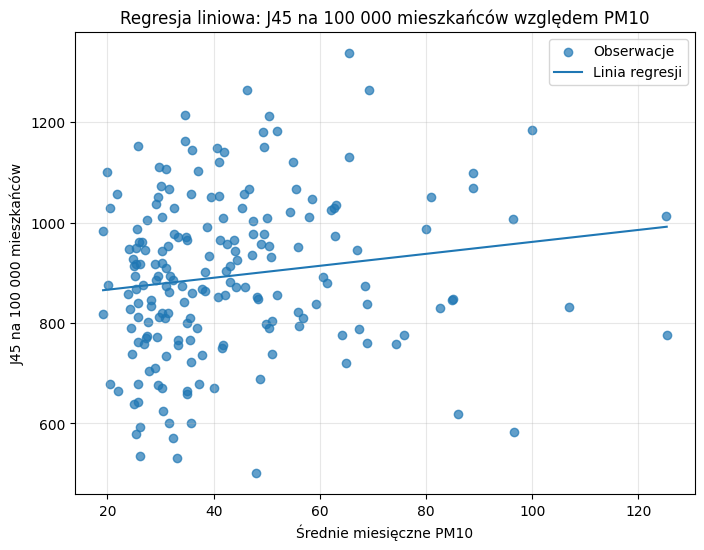

In [49]:
# Wykres punktowy z linią regresji
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(corr_data["PM10"], corr_data["J45_na_100k"], alpha=0.7, label="Obserwacje")

x_values = np.linspace(corr_data["PM10"].min(), corr_data["PM10"].max(), 100)
y_values = model.params["const"] + model.params["PM10"] * x_values

plt.plot(x_values, y_values, label="Linia regresji")

plt.title("Regresja liniowa: J45 na 100 000 mieszkańców względem PM10")
plt.xlabel("Średnie miesięczne PM10")
plt.ylabel("J45 na 100 000 mieszkańców")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [50]:
# Regresja osobno dla miast
for miasto in corr_data["Miasto"].unique():
    city_data = corr_data[corr_data["Miasto"] == miasto]
    
    X_city = sm.add_constant(city_data["PM10"])
    y_city = city_data["J45_na_100k"]
    
    model_city = sm.OLS(y_city, X_city).fit()
    
    print(f"\nRegresja dla miasta: {miasto}")
    print("Współczynnik PM10:", model_city.params["PM10"])
    print("p-value PM10:", model_city.pvalues["PM10"])
    print("R-squared:", model_city.rsquared)


Regresja dla miasta: Gliwice
Współczynnik PM10: 1.167135431069161
p-value PM10: 0.05071049265128688
R-squared: 0.040008511526497315

Regresja dla miasta: Tychy
Współczynnik PM10: 2.1086260089130446
p-value PM10: 0.017261451047473588
R-squared: 0.05883316853066489


# IV. Analiza szeregów czasowych
W analizie szeregów czasowych wykorzystano miesięczne wartości PM10 dla miasta Gliwice. Wybrano PM10, ponieważ zanieczyszczenie powietrza ma naturalny charakter czasowy i sezonowy — wartości mogą różnić się między miesiącami, szczególnie w sezonie grzewczym. Dane miesięczne obejmują lata 2007–2014, czyli 96 obserwacji.

# Uwzględnienie obu miast

In [51]:
# IV. Analiza szeregów czasowych - przygotowanie danych

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import periodogram
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

# Upewniamy się, że data istnieje
df_all["Data"] = pd.to_datetime(
    df_all["Rok"].astype(str) + "-" + df_all["Miesiac"].astype(str) + "-01"
)

# Zmienne numeryczne
df_all["PM10"] = pd.to_numeric(df_all["PM10"], errors="coerce")
df_all["J45_na_100k"] = pd.to_numeric(df_all["J45_na_100k"], errors="coerce")

def przygotuj_szereg(df, miasto, zmienna):
    """
    Funkcja przygotowuje miesięczny szereg czasowy dla wybranego miasta i zmiennej.
    Braki są uzupełniane interpolacją liniową, aby zachować ciągłość szeregu.
    """
    ts_data = df[df["Miasto"] == miasto].copy()
    ts_data = ts_data.sort_values("Data")
    
    ts = ts_data.set_index("Data")[zmienna]
    ts = ts.asfreq("MS")
    
    print(f"{miasto} - {zmienna}")
    print("Liczba obserwacji:", len(ts))
    print("Liczba braków przed interpolacją:", ts.isna().sum())
    
    ts_filled = ts.interpolate(method="linear")
    
    print("Liczba braków po interpolacji:", ts_filled.isna().sum())
    print()
    
    return ts_filled


# Szeregi czasowe PM10 i J45_na_100k dla obu miast

pm10_gliwice = przygotuj_szereg(df_all, "Gliwice", "PM10")
j45_gliwice = przygotuj_szereg(df_all, "Gliwice", "J45_na_100k")

pm10_tychy = przygotuj_szereg(df_all, "Tychy", "PM10")
j45_tychy = przygotuj_szereg(df_all, "Tychy", "J45_na_100k")

Gliwice - PM10
Liczba obserwacji: 96
Liczba braków przed interpolacją: 0
Liczba braków po interpolacji: 0

Gliwice - J45_na_100k
Liczba obserwacji: 96
Liczba braków przed interpolacją: 0
Liczba braków po interpolacji: 0

Tychy - PM10
Liczba obserwacji: 96
Liczba braków przed interpolacją: 0
Liczba braków po interpolacji: 0

Tychy - J45_na_100k
Liczba obserwacji: 96
Liczba braków przed interpolacją: 0
Liczba braków po interpolacji: 0



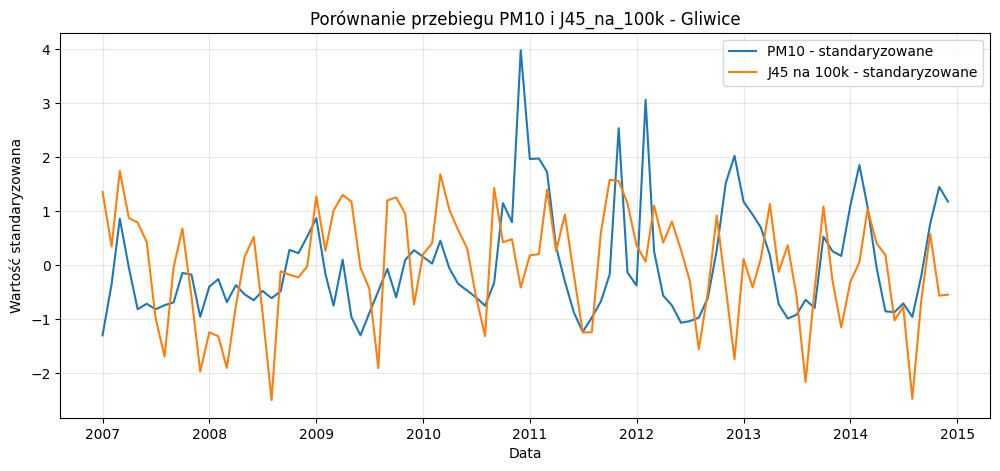

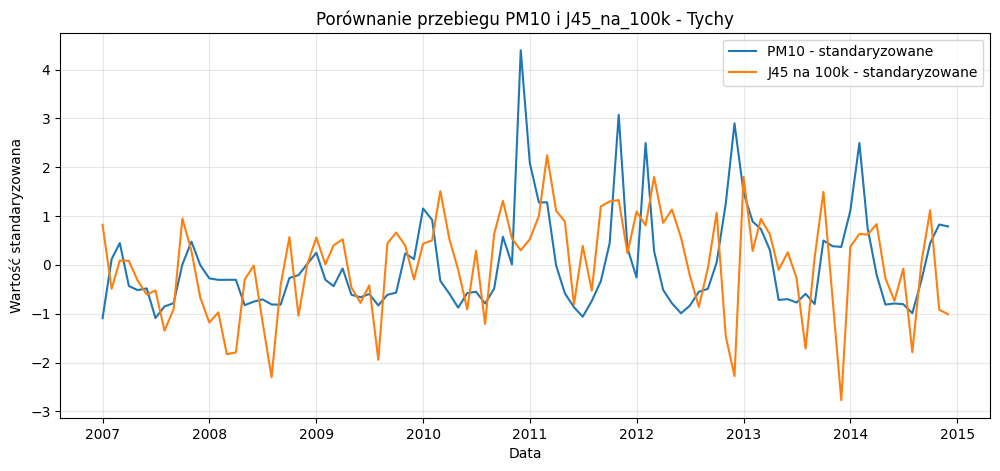

In [52]:
def wykres_porownawczy_standaryzowany(pm10_ts, j45_ts, miasto):
    """
    Wykres pokazuje przebieg PM10 i J45_na_100k w czasie po standaryzacji.
    Dzięki temu można porównywać kształt zmian mimo różnych jednostek.
    """
    pm10_z = (pm10_ts - pm10_ts.mean()) / pm10_ts.std()
    j45_z = (j45_ts - j45_ts.mean()) / j45_ts.std()
    
    plt.figure(figsize=(12, 5))
    plt.plot(pm10_z.index, pm10_z.values, label="PM10 - standaryzowane")
    plt.plot(j45_z.index, j45_z.values, label="J45 na 100k - standaryzowane")
    plt.title(f"Porównanie przebiegu PM10 i J45_na_100k - {miasto}")
    plt.xlabel("Data")
    plt.ylabel("Wartość standaryzowana")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

wykres_porownawczy_standaryzowany(pm10_gliwice, j45_gliwice, "Gliwice")
wykres_porownawczy_standaryzowany(pm10_tychy, j45_tychy, "Tychy")

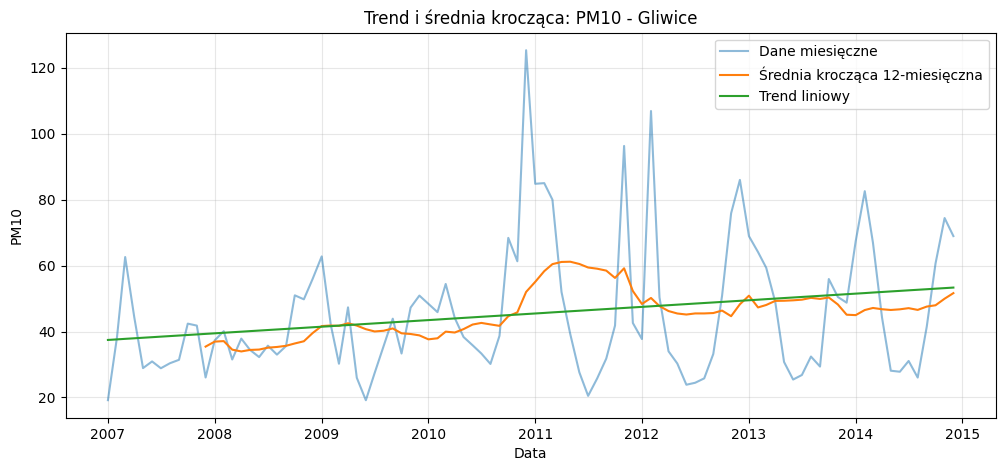

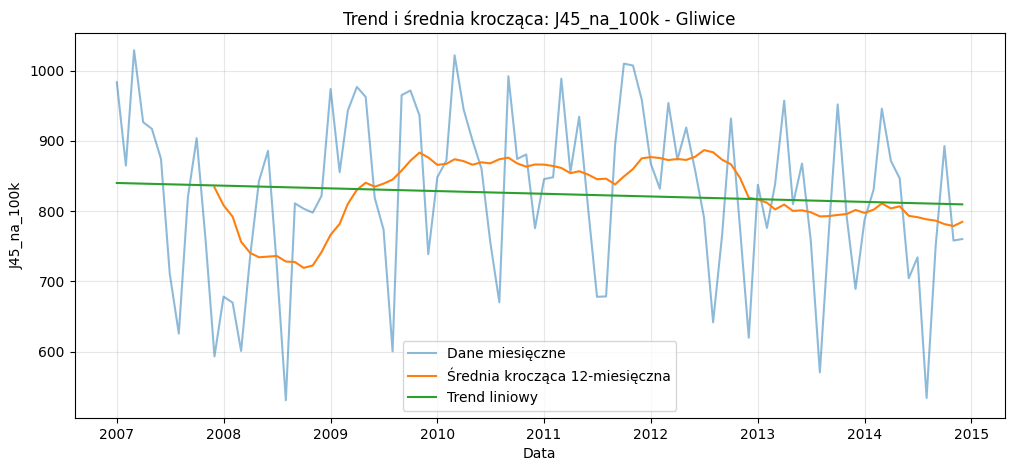

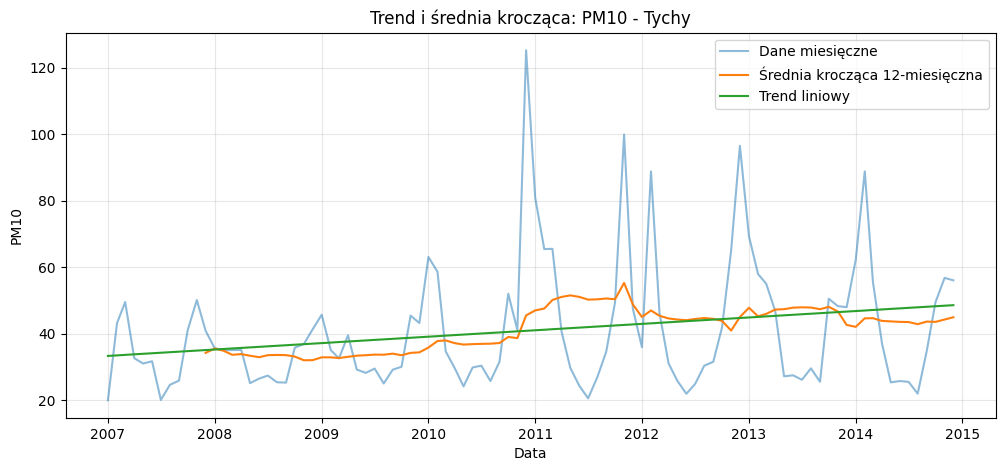

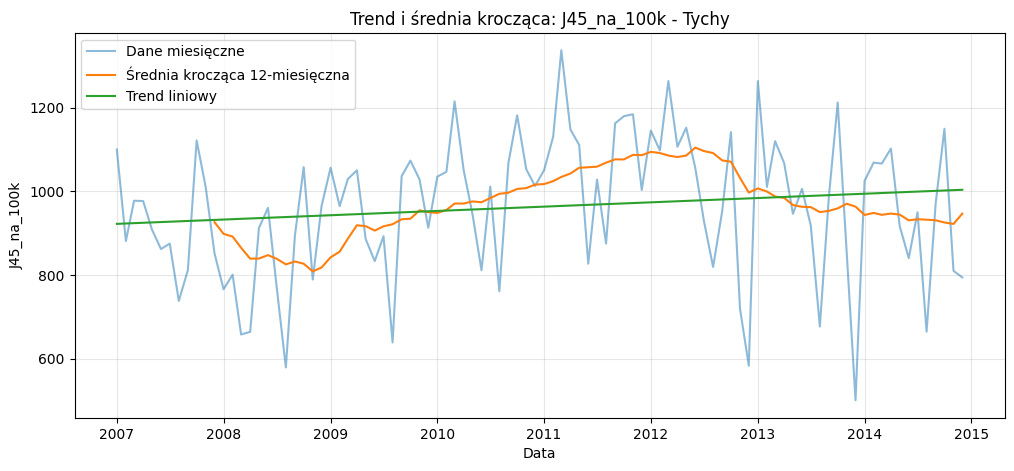

,Miasto,Zmienna,Współczynnik trendu,Interpretacja
0,Gliwice,PM10,0.167222,rosnący
1,Gliwice,J45_na_100k,-0.320239,malejący
2,Tychy,PM10,0.160821,rosnący
3,Tychy,J45_na_100k,0.857603,rosnący


In [53]:
def wykres_trendu_i_sredniej_kroczacej(ts, miasto, zmienna):
    rolling_12 = ts.rolling(window=12).mean()
    
    time_index = np.arange(len(ts))
    trend_coefficients = np.polyfit(time_index, ts.values, 1)
    trend_line = np.polyval(trend_coefficients, time_index)
    
    plt.figure(figsize=(12, 5))
    plt.plot(ts.index, ts.values, label="Dane miesięczne", alpha=0.5)
    plt.plot(rolling_12.index, rolling_12.values, label="Średnia krocząca 12-miesięczna")
    plt.plot(ts.index, trend_line, label="Trend liniowy")
    plt.title(f"Trend i średnia krocząca: {zmienna} - {miasto}")
    plt.xlabel("Data")
    plt.ylabel(zmienna)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return trend_coefficients[0]

trend_results = []

for miasto, pm10_ts, j45_ts in [
    ("Gliwice", pm10_gliwice, j45_gliwice),
    ("Tychy", pm10_tychy, j45_tychy)
]:
    trend_pm10 = wykres_trendu_i_sredniej_kroczacej(pm10_ts, miasto, "PM10")
    trend_j45 = wykres_trendu_i_sredniej_kroczacej(j45_ts, miasto, "J45_na_100k")
    
    trend_results.append({
        "Miasto": miasto,
        "Zmienna": "PM10",
        "Współczynnik trendu": trend_pm10,
        "Interpretacja": "rosnący" if trend_pm10 > 0 else "malejący" if trend_pm10 < 0 else "brak trendu"
    })
    
    trend_results.append({
        "Miasto": miasto,
        "Zmienna": "J45_na_100k",
        "Współczynnik trendu": trend_j45,
        "Interpretacja": "rosnący" if trend_j45 > 0 else "malejący" if trend_j45 < 0 else "brak trendu"
    })

trend_summary = pd.DataFrame(trend_results)
display(trend_summary)

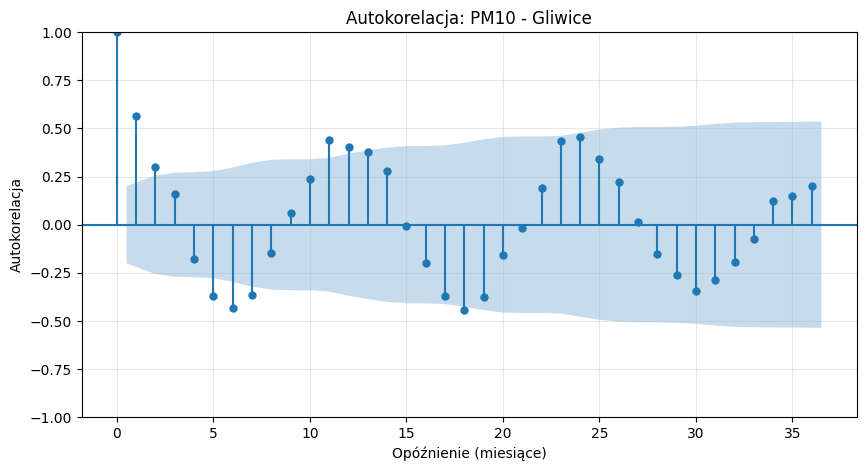

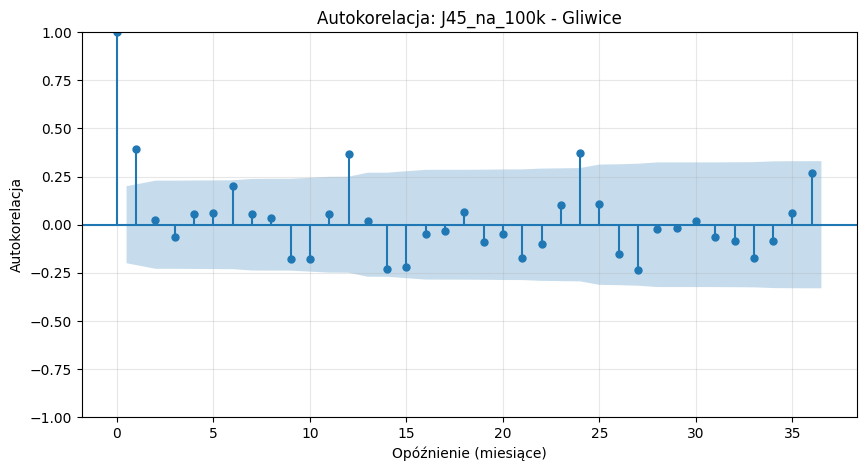

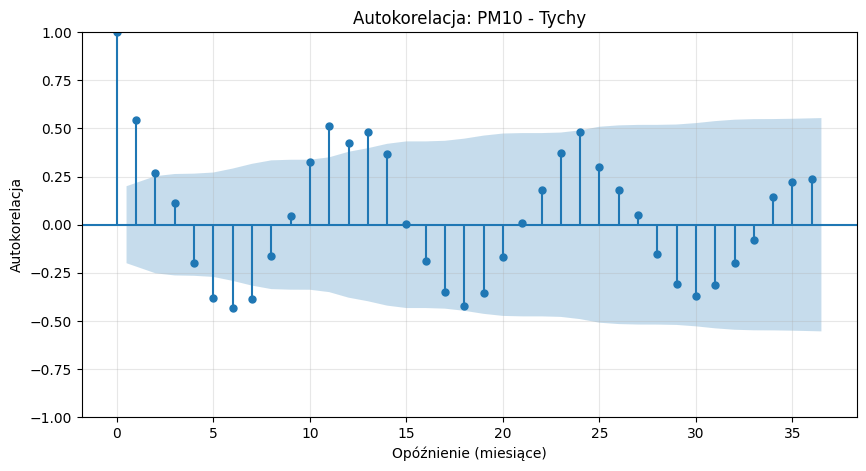

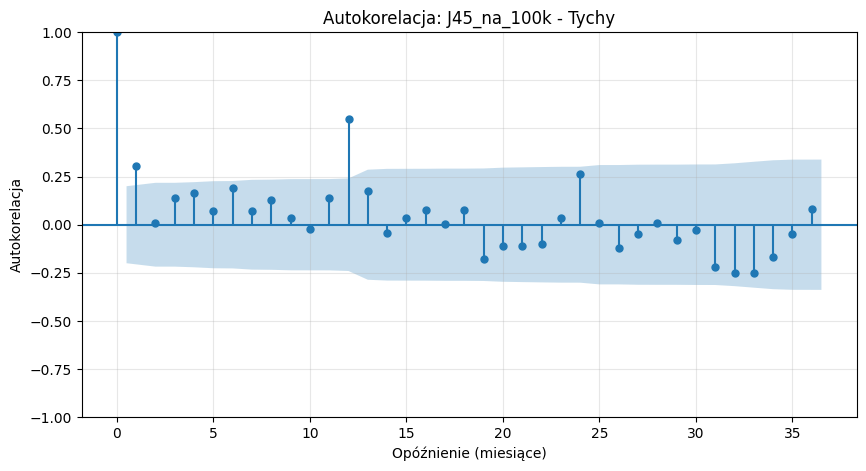

In [54]:
def pokaz_autokorelacje(ts, miasto, zmienna):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_acf(ts, lags=36, ax=ax)
    ax.set_title(f"Autokorelacja: {zmienna} - {miasto}")
    ax.set_xlabel("Opóźnienie (miesiące)")
    ax.set_ylabel("Autokorelacja")
    ax.grid(alpha=0.3)
    plt.show()

for miasto, pm10_ts, j45_ts in [
    ("Gliwice", pm10_gliwice, j45_gliwice),
    ("Tychy", pm10_tychy, j45_tychy)
]:
    pokaz_autokorelacje(pm10_ts, miasto, "PM10")
    pokaz_autokorelacje(j45_ts, miasto, "J45_na_100k")

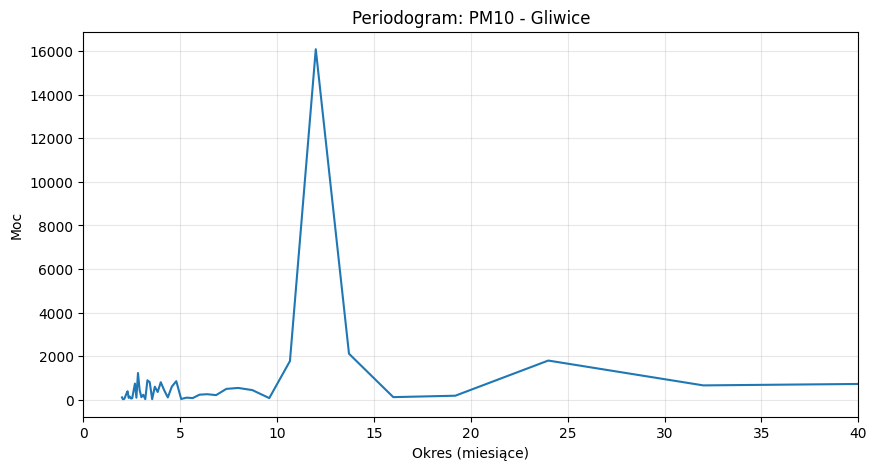

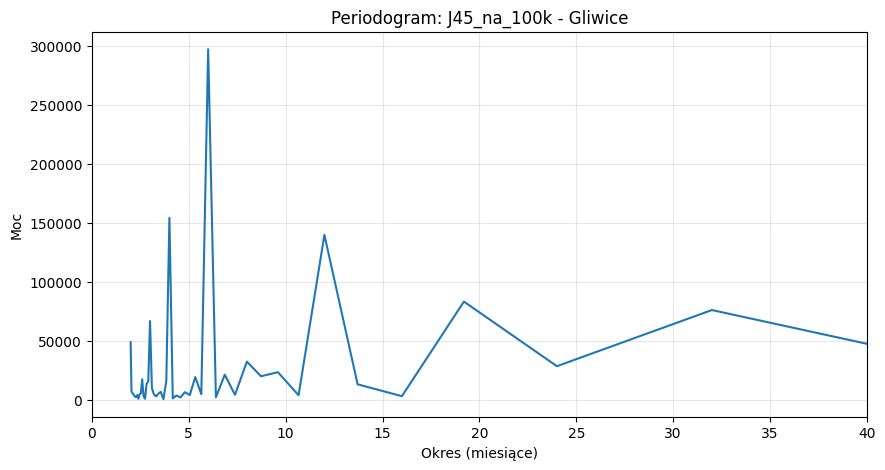

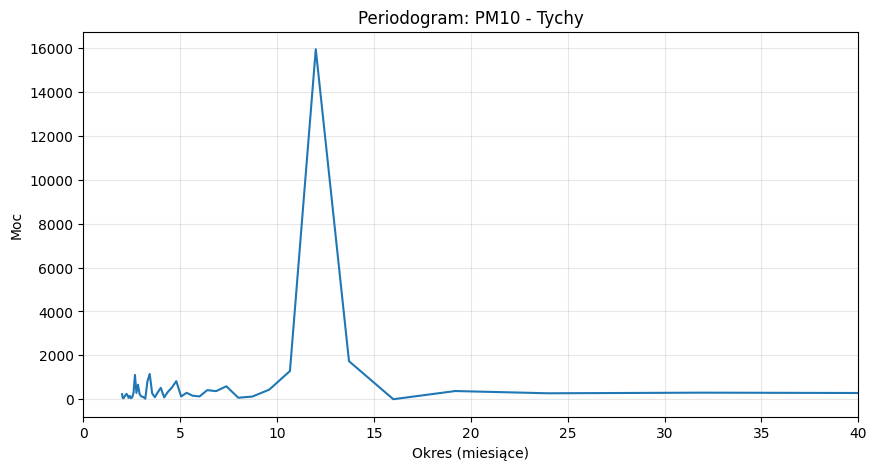

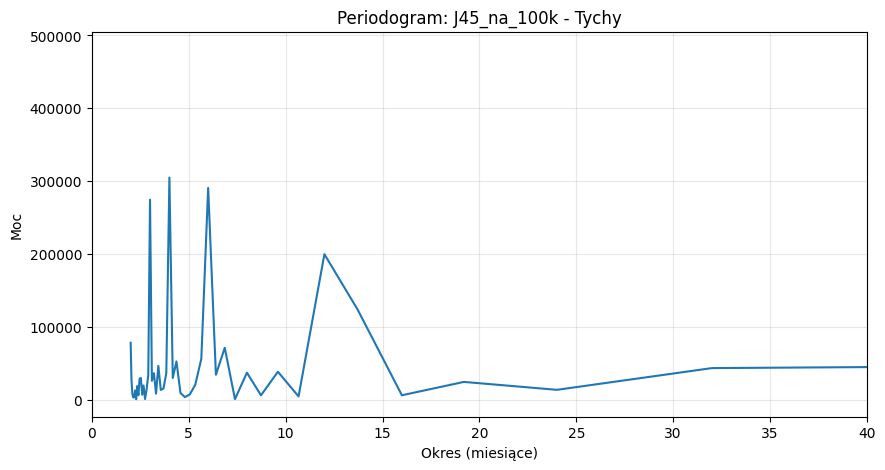

,Miasto,Zmienna,Okres_miesiace,Moc
0,Gliwice,PM10,12.000000,16093.966852
1,Gliwice,PM10,96.000000,2385.538604
2,Gliwice,PM10,13.714286,2108.756190
3,Gliwice,PM10,24.000000,1795.033199
4,Gliwice,PM10,10.666667,1771.493901
5,Gliwice,J45_na_100k,6.000000,297499.593227
6,Gliwice,J45_na_100k,4.000000,154367.958007
7,Gliwice,J45_na_100k,12.000000,139892.251821
8,Gliwice,J45_na_100k,96.000000,93795.565631
9,Gliwice,J45_na_100k,19.200000,83265.439339


In [55]:
def pokaz_periodogram(ts, miasto, zmienna):
    frequencies, power = periodogram(ts.values)
    
    frequencies_nonzero = frequencies[1:]
    power_nonzero = power[1:]
    periods = 1 / frequencies_nonzero
    
    plt.figure(figsize=(10, 5))
    plt.plot(periods, power_nonzero)
    plt.xlim(0, 40)
    plt.title(f"Periodogram: {zmienna} - {miasto}")
    plt.xlabel("Okres (miesiące)")
    plt.ylabel("Moc")
    plt.grid(alpha=0.3)
    plt.show()
    
    results = pd.DataFrame({
        "Miasto": miasto,
        "Zmienna": zmienna,
        "Okres_miesiace": periods,
        "Moc": power_nonzero
    }).sort_values("Moc", ascending=False)
    
    return results.head(5)

periodogram_tables = []

for miasto, pm10_ts, j45_ts in [
    ("Gliwice", pm10_gliwice, j45_gliwice),
    ("Tychy", pm10_tychy, j45_tychy)
]:
    periodogram_tables.append(pokaz_periodogram(pm10_ts, miasto, "PM10"))
    periodogram_tables.append(pokaz_periodogram(j45_ts, miasto, "J45_na_100k"))

periodogram_summary = pd.concat(periodogram_tables, ignore_index=True)
display(periodogram_summary)

,Miasto,Zmienna,Miesiac,Srednia_miesieczna,Wspolczynnik_sezonowosci
0,Gliwice,PM10,1,53.324217,1.174602
1,Gliwice,PM10,2,63.116292,1.390297
2,Gliwice,PM10,3,54.434786,1.199065
3,Gliwice,PM10,4,44.111387,0.971666
4,Gliwice,PM10,5,32.007996,0.705058
5,Gliwice,PM10,6,27.869778,0.613903
6,Gliwice,PM10,7,28.523798,0.628309
7,Gliwice,PM10,8,29.910510,0.658855
8,Gliwice,PM10,9,35.691429,0.786195
9,Gliwice,PM10,10,50.549176,1.113474


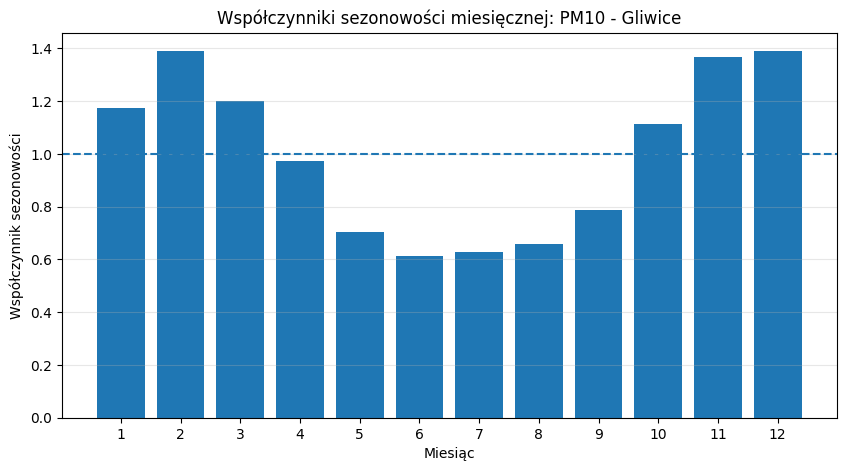

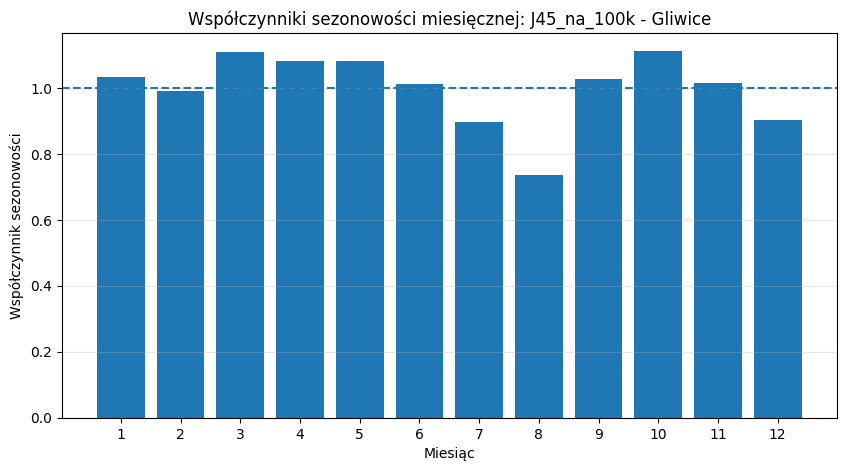

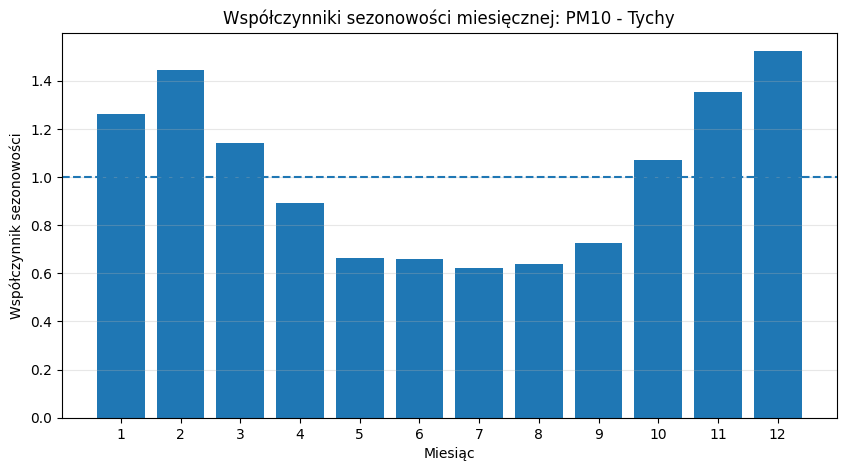

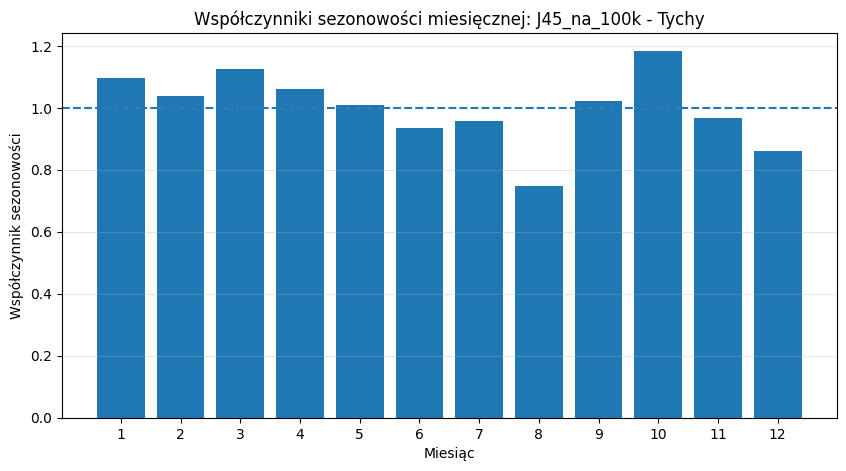

,Miasto,Zmienna,Miesiac,Srednia_miesieczna,Wspolczynnik_sezonowosci
21,Gliwice,J45_na_100k,10,917.352452,1.112231
14,Gliwice,J45_na_100k,3,915.127684,1.109534
15,Gliwice,J45_na_100k,4,892.552222,1.082162
1,Gliwice,PM10,2,63.116292,1.390297
11,Gliwice,PM10,12,63.074269,1.389372
10,Gliwice,PM10,11,62.158738,1.369205
45,Tychy,J45_na_100k,10,1140.035879,1.183500
38,Tychy,J45_na_100k,3,1083.727925,1.125045
36,Tychy,J45_na_100k,1,1055.580193,1.095825
35,Tychy,PM10,12,62.291994,1.523441


In [56]:
# Współczynniki sezonowości miesięcznej dla PM10 i J45_na_100k

def wspolczynniki_sezonowosci(ts, miasto, zmienna):
    seasonality_df = ts.reset_index()
    seasonality_df.columns = ["Data", zmienna]
    seasonality_df["Miesiac"] = seasonality_df["Data"].dt.month
    
    monthly_means = seasonality_df.groupby("Miesiac")[zmienna].mean()
    overall_mean = seasonality_df[zmienna].mean()
    
    coefficients = monthly_means / overall_mean
    
    result = pd.DataFrame({
        "Miasto": miasto,
        "Zmienna": zmienna,
        "Miesiac": monthly_means.index,
        "Srednia_miesieczna": monthly_means.values,
        "Wspolczynnik_sezonowosci": coefficients.values
    })
    
    return result

seasonality_results = pd.concat([
    wspolczynniki_sezonowosci(pm10_gliwice, "Gliwice", "PM10"),
    wspolczynniki_sezonowosci(j45_gliwice, "Gliwice", "J45_na_100k"),
    wspolczynniki_sezonowosci(pm10_tychy, "Tychy", "PM10"),
    wspolczynniki_sezonowosci(j45_tychy, "Tychy", "J45_na_100k")
], ignore_index=True)

display(seasonality_results)

# Wykresy współczynników sezonowości miesięcznej

for miasto in ["Gliwice", "Tychy"]:
    for zmienna in ["PM10", "J45_na_100k"]:
        temp = seasonality_results[
            (seasonality_results["Miasto"] == miasto) &
            (seasonality_results["Zmienna"] == zmienna)
        ]
        
        plt.figure(figsize=(10, 5))
        plt.bar(temp["Miesiac"], temp["Wspolczynnik_sezonowosci"])
        plt.axhline(1, linestyle="--")
        plt.title(f"Współczynniki sezonowości miesięcznej: {zmienna} - {miasto}")
        plt.xlabel("Miesiąc")
        plt.ylabel("Współczynnik sezonowości")
        plt.xticks(range(1, 13))
        plt.grid(axis="y", alpha=0.3)
        plt.show()
        
        # Miesiące o najwyższej sezonowości dla każdej zmiennej i miasta

top_seasonality = (
    seasonality_results
    .sort_values(["Miasto", "Zmienna", "Wspolczynnik_sezonowosci"], ascending=[True, True, False])
    .groupby(["Miasto", "Zmienna"])
    .head(3)
)

display(top_seasonality)

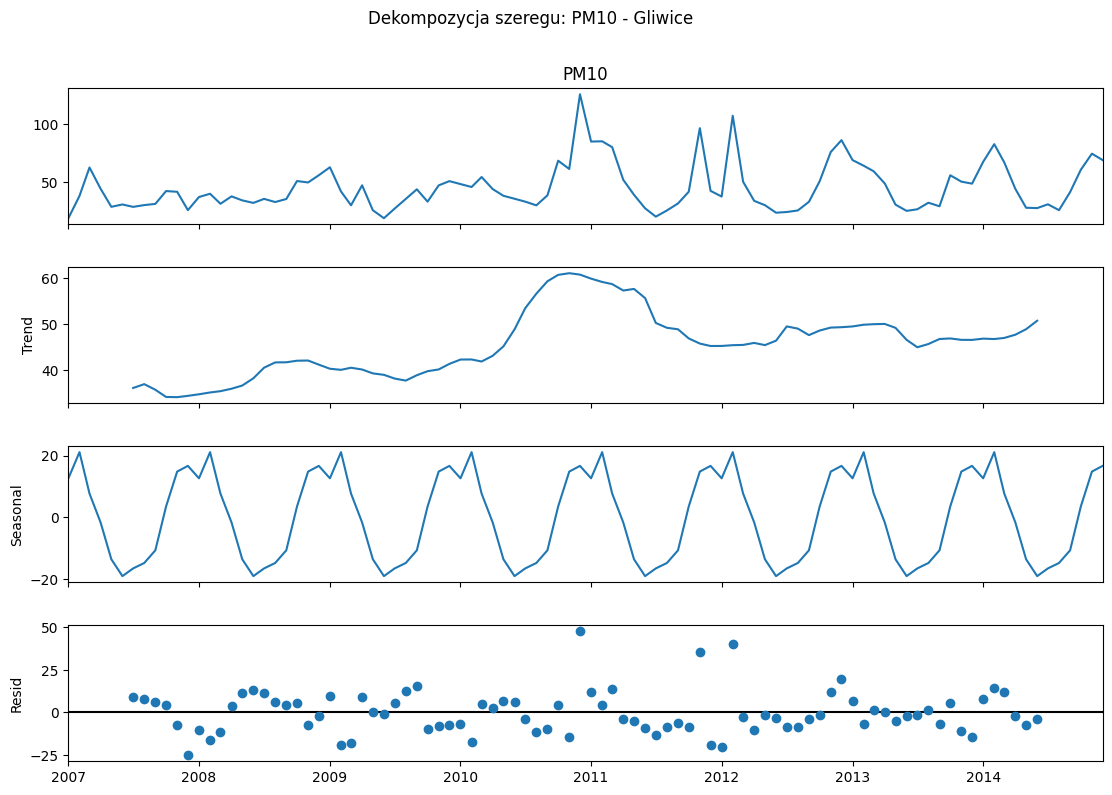

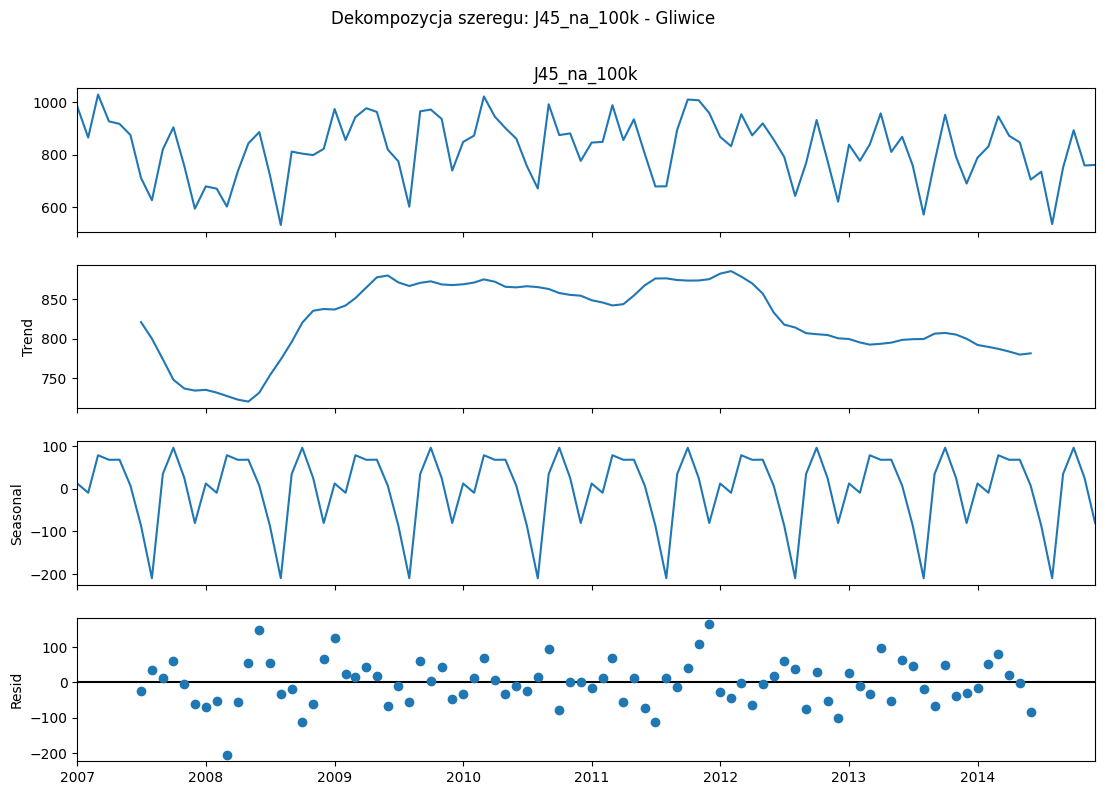

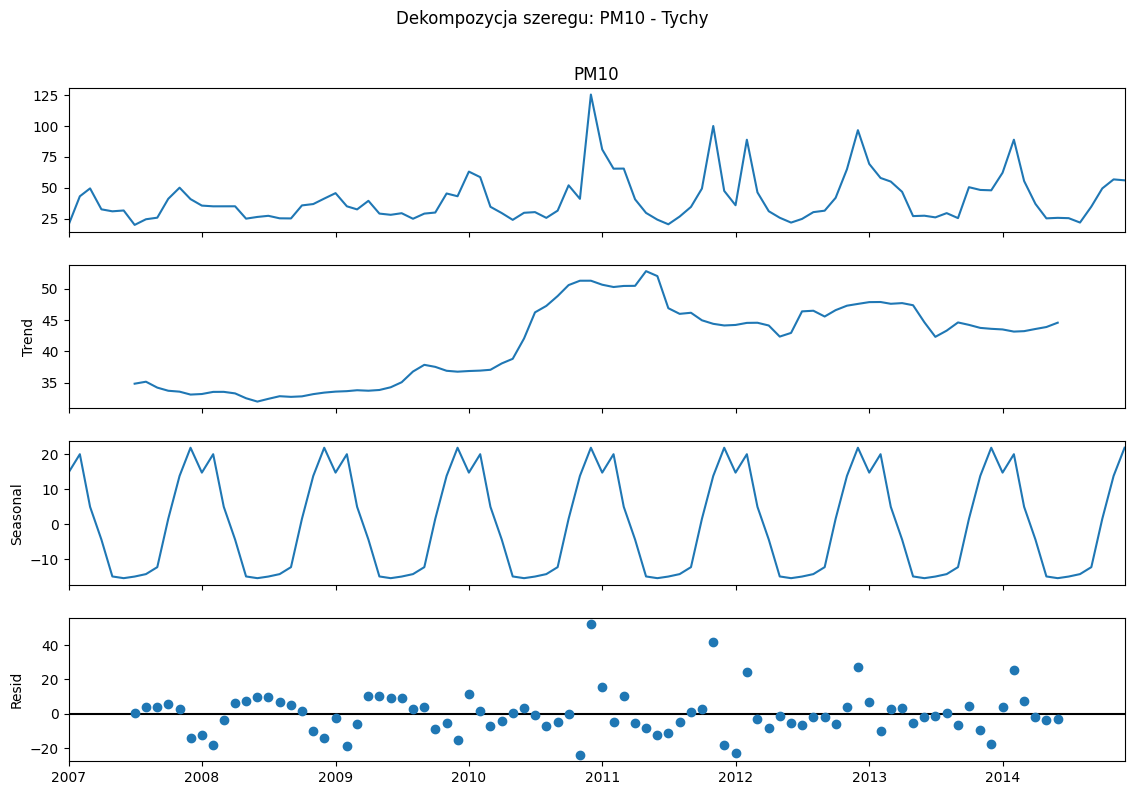

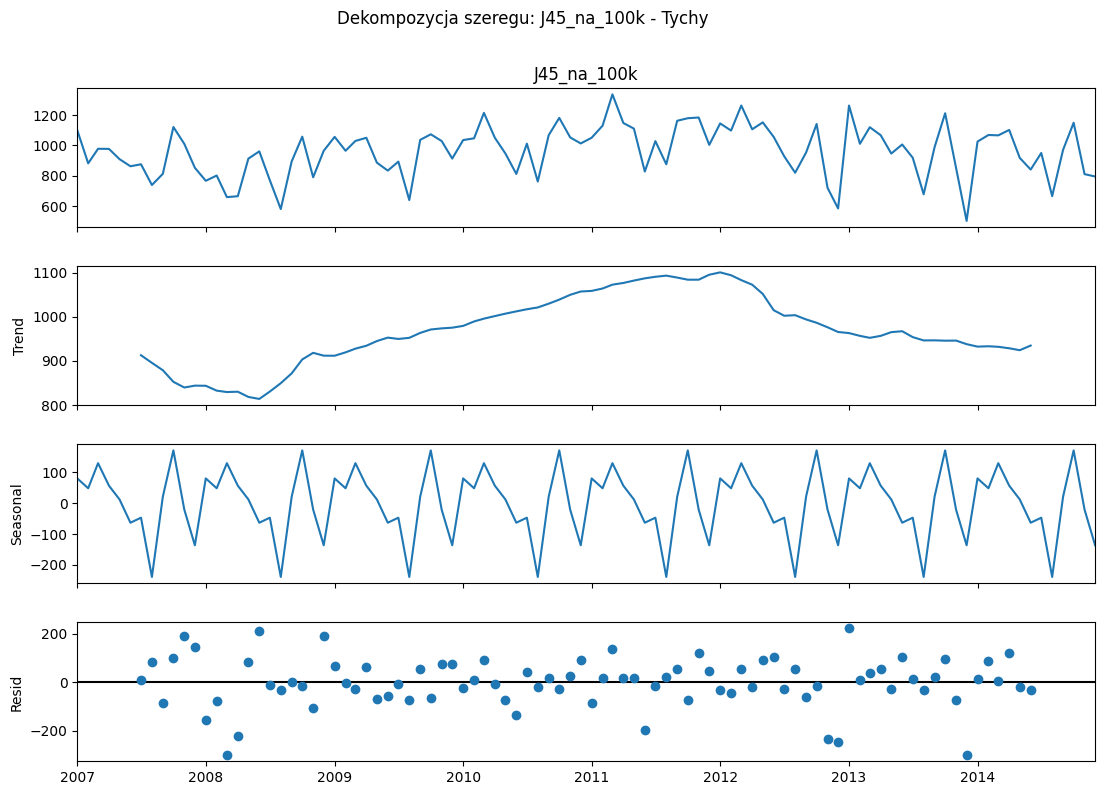

In [57]:
def pokaz_dekompozycje(ts, miasto, zmienna):
    decomposition = seasonal_decompose(
        ts,
        model="additive",
        period=12
    )
    
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"Dekompozycja szeregu: {zmienna} - {miasto}", y=1.02)
    plt.show()

for miasto, pm10_ts, j45_ts in [
    ("Gliwice", pm10_gliwice, j45_gliwice),
    ("Tychy", pm10_tychy, j45_tychy)
]:
    pokaz_dekompozycje(pm10_ts, miasto, "PM10")
    pokaz_dekompozycje(j45_ts, miasto, "J45_na_100k")

In [58]:
# Korelacja PM10 z J45_na_100k z opóźnieniem

lag_results = []

for miasto in ["Gliwice", "Tychy"]:
    temp = df_all[df_all["Miasto"] == miasto].copy()
    temp = temp.sort_values("Data")
    
    temp["PM10"] = pd.to_numeric(temp["PM10"], errors="coerce")
    temp["J45_na_100k"] = pd.to_numeric(temp["J45_na_100k"], errors="coerce")
    
    for lag in range(0, 4):
        temp[f"PM10_lag_{lag}"] = temp["PM10"].shift(lag)
        
        corr = temp[[f"PM10_lag_{lag}", "J45_na_100k"]].corr().iloc[0, 1]
        
        lag_results.append({
            "Miasto": miasto,
            "Opóźnienie PM10": lag,
            "Opis": "ten sam miesiąc" if lag == 0 else f"PM10 sprzed {lag} mies.",
            "Korelacja z J45_na_100k": corr
        })

lag_results_df = pd.DataFrame(lag_results)
display(lag_results_df)

,Miasto,Opóźnienie PM10,Opis,Korelacja z J45_na_100k
0,Gliwice,0,ten sam miesiąc,0.200021
1,Gliwice,1,PM10 sprzed 1 mies.,0.256965
2,Gliwice,2,PM10 sprzed 2 mies.,0.216363
3,Gliwice,3,PM10 sprzed 3 mies.,0.221275
4,Tychy,0,ten sam miesiąc,0.242555
5,Tychy,1,PM10 sprzed 1 mies.,0.311576
6,Tychy,2,PM10 sprzed 2 mies.,0.331756
7,Tychy,3,PM10 sprzed 3 mies.,0.327787
